# Laporan Tugas Besar: Pembangunan Model pada Berbagai Teknik Pre-processing

**Dataset**: `scabies_sapi.csv`

**Fokus Analisis**: **Decission Tree** sebagai base model utama

**Tujuan**:
Notebook ini bertujuan untuk melakukan analisis komprehensif terhadap berbagai teknik pra-pemrosesan (pre-processing) data dan membandingkan dampaknya terhadap kinerja beberapa algoritma Machine Learning, dengan **Decission Tree** sebagai model utama yang dianalisis secara mendalam. Berbagai kombinasi preprocessing (scaling, encoding, imbalance handling) diuji secara sistematis untuk menemukan pipeline terbaik.

## STEP 1 - Import Library

### Teori Singkat
Dalam pengembangan model Machine Learning, berbagai library Python digunakan untuk memfasilitasi manipulasi data, visualisasi, dan pemodelan.
- **Pandas & NumPy**: Manipulasi data dan komputasi numerik.
- **Seaborn & Matplotlib**: Visualisasi data.
- **Scikit-learn (sklearn)**: Algoritma ML, evaluasi metrik, dan teknik pre-processing.
- **Imbalanced-learn (imblearn)**: Menangani masalah data tidak seimbang (SMOTE, ADASYN, RandomUnderSampler).
- **Decission Tree**: metode visual dan matematis yang memetakan berbagai pilihan alternatif, probabilitas peristiwa, dan konsekuensinya.

### Tujuan Step
Menginisialisasi semua fungsi dan modul yang akan digunakan di seluruh tahapan eksperimen.

### Perbedaan dengan Metode Sebelumnya
- Sebelumnya, hanya menggunakan 4 model dasar (Logistic Regression, Decision Tree, Random Forest, KNN biasa).
- Sekarang, **Random Forest** menjadi fokus utama analisis sebagai base model, ditambahkan **XGBoost** sebagai model ke-5 untuk perbandingan, KNN diubah menjadi **Weighted KNN** (W-KNN) dengan parameter weights='distance', serta berbagai teknik preprocessing tambahan (MinMaxScaler, RobustScaler, ADASYN, RandomUnderSampler) untuk perbandingan yang lebih komprehensif.
- **Random Forest** dipilih sebagai fokus karena merupakan algoritma ensemble yang sangat populer dan sering menjadi baseline kuat dalam berbagai kompetisi ML.

In [85]:
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree # Tambahan: Untuk memvisualisasikan aturan Decision Tree

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
# Catatan: Scaler (StandardScaler/MinMaxScaler) dihapus karena Decision Tree 
# tidak sensitif terhadap perbedaan skala data/outlier.

# Handling Imbalance (Tetap disisakan jika data target Anda tidak seimbang)
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

# Machine Learning Models - Difokuskan HANYA pada Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Evaluasi
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

import warnings
warnings.filterwarnings('ignore')

print("Semua library untuk analisis Decision Tree berhasil diimport!")

Semua library untuk analisis Decision Tree berhasil diimport!


## STEP 2 - Load Dataset

### Teori Singkat
Proses pemuatan data (data loading) adalah langkah awal sebelum analisis dilakukan. Dataset harus direpresentasikan dalam bentuk struktur data yang dapat diproses oleh mesin, seperti DataFrame pandas.

### Tujuan Step
Membaca dataset `scabies_sapi.csv` dan menginspeksi beberapa baris awal serta dimensi dari dataset tersebut.

In [86]:
import os

print("1. Python sedang berjalan di folder ini:")
print(os.getcwd())

print("\n2. Daftar file yang ada di dalam folder tersebut:")
for file in os.listdir():
    print(f"- {file}")

1. Python sedang berjalan di folder ini:
d:\Machine Learning\aplikasiMachLearn

2. Daftar file yang ada di dalam folder tersebut:
- .git
- .gitignore
- app.py
- dataset
- dataset.ipynb
- models
- pages
- Pembangunan_Model_Preprocessing.ipynb
- Pembangunan_Model_Preprocessing_Decission_Tree.ipynb
- README.md
- requirements.txt
- utils


In [87]:
# Load dataset
df = pd.read_csv('dataset/scabies-sapi.csv') 

display(df.head())

# Menampilkan ukuran dataset
print(f"Jumlah baris (Data)  : {df.shape[0]}")
print(f"Jumlah kolom (Fitur) : {df.shape[1]}")

,usia,jenis_kelamin,kondisi_kandang,kepadatan_kandang,gatal,kerontokan_bulu,kerak_pada_kulit,luka_lecet,nafsu_makan,hasil_tes_laboratorium
0,2,Female,Bersih,Rendah,TIDAK,TIDAK,TIDAK,TIDAK,Menurun,NEGATIF
1,3,Female,Kotor,Tinggi,YA,YA,YA,YA,Menurun,POSITIF
2,3,Female,Bersih,Sedang,YA,TIDAK,YA,YA,Menurun,POSITIF
3,2,Female,Bersih,Sedang,TIDAK,YA,TIDAK,TIDAK,Normal,NEGATIF
4,1,Male,Bersih,Rendah,TIDAK,TIDAK,TIDAK,TIDAK,Normal,NEGATIF


Jumlah baris (Data)  : 2500
Jumlah kolom (Fitur) : 10


### Analisis Hasil
Dataset telah berhasil dimuat dengan 5110 sampel dan 12 fitur. Target dari dataset ini adalah fitur `scabies`, di mana model harus memprediksi apakah seorang pasien berisiko mengalami scabies
 atau tidak berdasarkan fitur klinis lainnya.

## STEP 3 - Informasi Dataset

### Teori Singkat
Pemeriksaan struktur dataset melibatkan pengamatan tipe data (integer, float, object), keberadaan nilai kosong (missing values), dan keberadaan data duplikat. Analisis deskriptif juga diperlukan untuk melihat distribusi statistik dari fitur numerik.

### Tujuan Step
Mendapatkan pemahaman mendalam tentang tipe data masing-masing kolom dan mengidentifikasi anomali seperti nilai kosong atau baris yang terduplikasi.

In [88]:
# Menampilkan informasi struktur dataframe
print("=" * 60)
print("INFORMASI DATASET")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("STATISTIK DESKRIPTIF (NUMERIK)")
print("=" * 60)
display(df.describe())

print("\n" + "=" * 60)
print("MISSING VALUE PER FITUR")
print("=" * 60)
print(df.isnull().sum())

print("\n" + "=" * 60)
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")
print("=" * 60)

INFORMASI DATASET
<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   usia                    2500 non-null   int64
 1   jenis_kelamin           2500 non-null   str  
 2   kondisi_kandang         2500 non-null   str  
 3   kepadatan_kandang       2500 non-null   str  
 4   gatal                   2500 non-null   str  
 5   kerontokan_bulu         2500 non-null   str  
 6   kerak_pada_kulit        2500 non-null   str  
 7   luka_lecet              2500 non-null   str  
 8   nafsu_makan             2500 non-null   str  
 9   hasil_tes_laboratorium  2500 non-null   str  
dtypes: int64(1), str(9)
memory usage: 307.0 KB

STATISTIK DESKRIPTIF (NUMERIK)


,usia
count,2500.000000
mean,2.196000
std,0.759615
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,3.000000



MISSING VALUE PER FITUR
usia                      0
jenis_kelamin             0
kondisi_kandang           0
kepadatan_kandang         0
gatal                     0
kerontokan_bulu           0
kerak_pada_kulit          0
luka_lecet                0
nafsu_makan               0
hasil_tes_laboratorium    0
dtype: int64

Jumlah baris duplikat: 1945


In [89]:
# ==========================================
# STEP 4: DATA CLEANING & INTEGRITY CHECK
# ==========================================

print("=== Kondisi Data Sebelum Cleaning ===")
print(df.isnull().sum())
print(f"Ukuran dataset awal: {df.shape}")

# 1. Menghapus data duplikat (sangat penting agar model tidak over-fitting ke data yang berulang)
initial_shape = df.shape
df = df.drop_duplicates()
final_shape = df.shape
print(f"\n-> Menghapus {initial_shape[0] - final_shape[0]} baris data duplikat.")

# 2. Menangani Missing Value (Jika ada)
# Mengingat fitur dominan adalah kategorikal (YA/TIDAK, Male/Female), 
# jika ada data yang kosong, lebih aman menggunakan Modus (nilai yang paling sering muncul).
# Namun jika dataset sudah bersih, kode ini hanya bertindak sebagai pengaman.
for col in df.columns:
    if df[col].isnull().sum() > 0:
        # Gunakan modus untuk mengisi kekosongan data
        modus_val = df[col].mode()[0]
        df[col] = df[col].fillna(modus_val)
        print(f"-> Missing value pada kolom '{col}' diisi dengan Modus: {modus_val}")

# 3. Noise Reduction (Memastikan kategori jenis kelamin sesuai)
# Berjaga-jaga jika ada input salah ketik selain 'Male' atau 'Female'
df = df[df['jenis_kelamin'].isin(['Male', 'Female'])]

# ==========================================
# VERIFIKASI AKHIR
# ==========================================
print("\n=== Jumlah Missing Value Setelah Cleaning ===")
print(df.isnull().sum())
print(f"\nUkuran dataset siap pakai (setelah cleaning): {df.shape}")

=== Kondisi Data Sebelum Cleaning ===
usia                      0
jenis_kelamin             0
kondisi_kandang           0
kepadatan_kandang         0
gatal                     0
kerontokan_bulu           0
kerak_pada_kulit          0
luka_lecet                0
nafsu_makan               0
hasil_tes_laboratorium    0
dtype: int64
Ukuran dataset awal: (2500, 10)

-> Menghapus 1945 baris data duplikat.

=== Jumlah Missing Value Setelah Cleaning ===
usia                      0
jenis_kelamin             0
kondisi_kandang           0
kepadatan_kandang         0
gatal                     0
kerontokan_bulu           0
kerak_pada_kulit          0
luka_lecet                0
nafsu_makan               0
hasil_tes_laboratorium    0
dtype: int64

Ukuran dataset siap pakai (setelah cleaning): (555, 10)


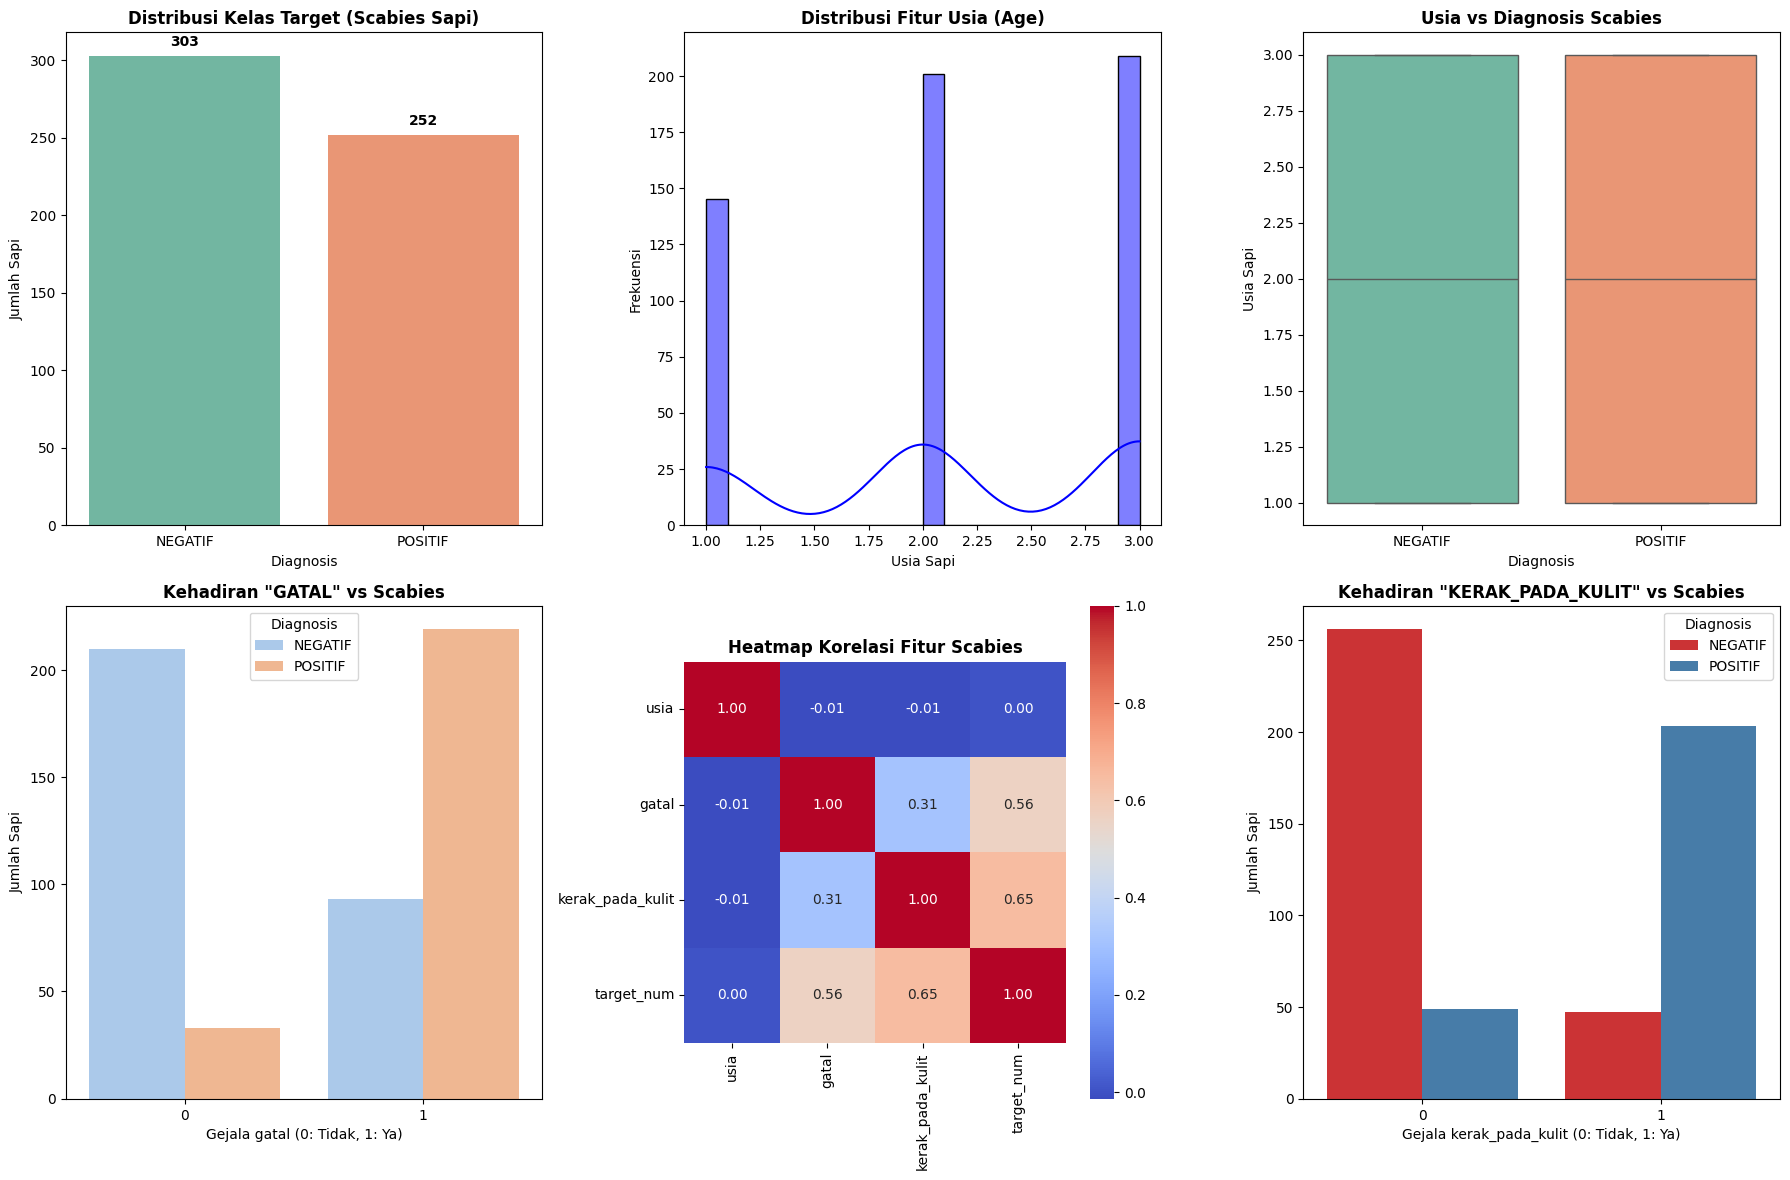


ANALISIS CLASS IMBALANCE (SCABIES SAPI)
Kelas NEGATIF  :   303 sapi ( 54.6%)
Kelas POSITIF  :   252 sapi ( 45.4%)
Rasio Imbalance           : 1 : 1


In [92]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# KONFIGURASI NAMA KOLOM (SESUAIKAN DENGAN CSV ABANG)
# ==========================================
TARGET_KOLOM = 'hasil_tes_laboratorium'  # Target column: (POSITIF/NEGATIF) or 0/1
GEJALA_1 = 'gatal'                        # Gejala 1: (YA/TIDAK) or 0/1
GEJALA_2 = 'kerak_pada_kulit'             # Gejala 2: (YA/TIDAK) or 0/1
# ==========================================

# Work on a copy so we don't accidentally mutate original df used later
df_plot = df.copy()

# Validate required columns
missing = [c for c in (TARGET_KOLOM, 'usia', GEJALA_1, GEJALA_2) if c not in df_plot.columns]
if missing:
    raise KeyError(f"Kolom yang hilang di dataframe: {missing}")

# Normalize target to textual labels 'NEGATIF' / 'POSITIF' for plotting clarity
unique_vals = df_plot[TARGET_KOLOM].dropna().unique()
if set(np.unique(unique_vals)).issubset({0, 1}):
    df_plot['__target_label'] = df_plot[TARGET_KOLOM].map({0: 'NEGATIF', 1: 'POSITIF'})
else:
    # Map common variants (case-insensitive) to standardized labels
    df_plot['__target_label'] = df_plot[TARGET_KOLOM].astype(str).str.upper().map(
        lambda x: 'POSITIF' if 'POS' in x else ('NEGATIF' if 'NEG' in x else x)
    )

# Helper to normalize binary symptom columns to 0/1 when they are strings like 'YA'/'TIDAK'
def _normalize_binary_col(col):
    vals = df_plot[col].dropna().unique()
    if set(np.unique(vals)).issubset({0, 1}):
        return
    df_plot[col] = df_plot[col].astype(str).str.upper().map(
        lambda x: 1 if x.startswith('Y') or 'YA' in x else (0 if x.startswith('T') or 'TIDAK' in x or x.startswith('N') else np.nan)
    )

_normalize_binary_col(GEJALA_1)
_normalize_binary_col(GEJALA_2)

plt.figure(figsize=(18, 12))

# 1. Distribusi Kelas Target
plt.subplot(2, 3, 1)
order = ['NEGATIF', 'POSITIF'] if set(['NEGATIF', 'POSITIF']).issubset(set(df_plot['__target_label'].unique())) else sorted(df_plot['__target_label'].unique())
ax = sns.countplot(data=df_plot, x='__target_label', order=order, palette='Set2')
plt.title('Distribusi Kelas Target (Scabies Sapi)', fontweight='bold')
plt.xlabel('Diagnosis')
plt.ylabel('Jumlah Sapi')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontweight='bold', xytext=(0, 5), textcoords='offset points')

# 2. Distribusi Usia
plt.subplot(2, 3, 2)
sns.histplot(df_plot['usia'].dropna(), kde=True, color='blue', bins=20)
plt.title('Distribusi Fitur Usia (Age)', fontweight='bold')
plt.xlabel('Usia Sapi')
plt.ylabel('Frekuensi')

# 3. Usia vs Target (boxplot)
plt.subplot(2, 3, 3)
sns.boxplot(data=df_plot, x='__target_label', y='usia', palette='Set2')
plt.title('Usia vs Diagnosis Scabies', fontweight='bold')
plt.xlabel('Diagnosis')
plt.ylabel('Usia Sapi')

# 4. Distribusi Gejala 1 vs Target
plt.subplot(2, 3, 4)
sns.countplot(data=df_plot, x=GEJALA_1, hue='__target_label', palette='pastel')
plt.title(f'Kehadiran "{GEJALA_1.upper()}" vs Scabies', fontweight='bold')
plt.xlabel(f'Gejala {GEJALA_1} (0: Tidak, 1: Ya)')
plt.ylabel('Jumlah Sapi')
plt.legend(title='Diagnosis')

# 5. Correlation Heatmap (numeric only)
plt.subplot(2, 3, 5)
numeric_df = df_plot.select_dtypes(include=[np.number]).copy()
# add numeric target if possible for correlation
if '__target_label' in df_plot.columns:
    numeric_df['target_num'] = df_plot['__target_label'].map({'NEGATIF': 0, 'POSITIF': 1})
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Heatmap Korelasi Fitur Scabies', fontweight='bold')

# 6. Distribusi Gejala 2 vs Target
plt.subplot(2, 3, 6)
sns.countplot(data=df_plot, x=GEJALA_2, hue='__target_label', palette='Set1')
plt.title(f'Kehadiran "{GEJALA_2.upper()}" vs Scabies', fontweight='bold')
plt.xlabel(f'Gejala {GEJALA_2} (0: Tidak, 1: Ya)')
plt.ylabel('Jumlah Sapi')
plt.legend(title='Diagnosis')

plt.tight_layout()
plt.show()

# ANALISIS IMBALANCE (tahan format label apa pun)
print("\n" + "=" * 50)
print("ANALISIS CLASS IMBALANCE (SCABIES SAPI)")
print("=" * 50)
counts = df_plot['__target_label'].value_counts()
for lbl, cnt in counts.items():
    pct = cnt / len(df_plot) * 100
    print(f"Kelas {lbl:8} : {cnt:5} sapi ({pct:5.1f}%)")

neg = counts.get('NEGATIF', 0)
pos = counts.get('POSITIF', 0)
rasio = (neg // pos) if pos > 0 else 'Tak Terhingga'
print(f"Rasio Imbalance           : 1 : {rasio}")


In [ ]:
print("=== Fitur Kategorikal dan Jumlah Unique Values ===")
# Mendeteksi otomatis kolom mana saja yang berisi teks (object)
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"  {col}: {df[col].nunique()} kategori -> {df[col].unique()}")

# CATATAN MEDIS & MACHINE LEARNING:
# Mayoritas fitur kita adalah biner (2 kategori: YA/TIDAK, POSITIF/NEGATIF).
# Khusus 'kepadatan_kandang' memiliki 3 kategori (Rendah, Sedang, Tinggi).
# Algoritma Decision Tree kebal terhadap masalah skala, sehingga kita tetap 
# AMAN menggunakan Label Encoding untuk semua kolom tanpa harus memakai One-Hot Encoding.

print("\n=== Proses Label Encoding ===")
le_dict = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le
    
    # Menampilkan kamus perubahan dari Teks ke Angka (misal: 'TIDAK' -> 0, 'YA' -> 1)
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"Label Encoding '{col}': {mapping}")

print(f"\n{'=' * 50}")
print(f"Shape dataset setelah encoding: {df.shape}")
print(f"Daftar Kolom: {df.columns.tolist()}")

print("\n=== Preview Data Setelah Encoding ===")
display(df.head())

=== Fitur Kategorikal dan Jumlah Unique Values ===

=== Proses Label Encoding ===

Shape dataset setelah encoding: (555, 10)
Daftar Kolom: ['usia', 'jenis_kelamin', 'kondisi_kandang', 'kepadatan_kandang', 'gatal', 'kerontokan_bulu', 'kerak_pada_kulit', 'luka_lecet', 'nafsu_makan', 'hasil_tes_laboratorium']

=== Preview Data Setelah Encoding ===


,usia,jenis_kelamin,kondisi_kandang,kepadatan_kandang,gatal,kerontokan_bulu,kerak_pada_kulit,luka_lecet,nafsu_makan,hasil_tes_laboratorium
0,2,0,0,0,0,0,0,0,0,0
1,3,0,1,2,1,1,1,1,0,1
2,3,0,0,1,1,0,1,1,0,1
3,2,0,0,1,0,1,0,0,1,0
4,1,1,0,0,0,0,0,0,1,0


In [ ]:
# ==========================================
# STEP 6: PEMISAHAN DATA (TRAIN-TEST SPLIT)
# ==========================================

# Pemisahan X (Fitur/Gejala) dan y (Target/Hasil Lab)
X = df.drop('hasil_tes_laboratorium', axis=1)
y = df['hasil_tes_laboratorium']

# Stratified Train-Test Split (mempertahankan proporsi kelas Positif/Negatif)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=== Informasi Pemisahan Dataset ===")
print(f"Dimensi X_train (Data Latih) : {X_train.shape}")
print(f"Dimensi X_test (Data Uji)    : {X_test.shape}")

print(f"\nDistribusi Kelas Target di Train Set (Data Latih):")
# Catatan: 0 dan 1 merujuk pada hasil Label Encoding sebelumnya
print(y_train.value_counts())

print(f"\nDistribusi Kelas Target di Test Set (Data Uji):")
print(y_test.value_counts())

# Menghitung proporsi kelas 1 (biasanya POSITIF karena urutan alfabet P setelah N)
print(f"\nProporsi Kelas 1 (Positif) di Data Latih : {y_train.mean():.4f}")
print(f"Proporsi Kelas 1 (Positif) di Data Uji   : {y_test.mean():.4f}")

=== Informasi Pemisahan Dataset ===
Dimensi X_train (Data Latih) : (444, 9)
Dimensi X_test (Data Uji)    : (111, 9)

Distribusi Kelas Target di Train Set (Data Latih):
hasil_tes_laboratorium
0    242
1    202
Name: count, dtype: int64

Distribusi Kelas Target di Test Set (Data Uji):
hasil_tes_laboratorium
0    61
1    50
Name: count, dtype: int64

Proporsi Kelas 1 (Positif) di Data Latih : 0.4550
Proporsi Kelas 1 (Positif) di Data Uji   : 0.4505


In [91]:
# ==========================================
# STEP 7: FEATURE SCALING (Eksperimen Numerik)
# ==========================================

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Inisialisasi 3 jenis Scaler + 1 skenario tanpa scaling
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler(),
    'Tanpa Scaling': None
}

# Dictionary untuk menyimpan data yang sudah di-scale
scaled_data = {}

for scaler_name, scaler in scalers.items():
    if scaler is not None:
        # Gunakan .copy() agar data asli tidak ikut berubah
        X_train_sc = X_train.copy()
        X_test_sc = X_test.copy()
        
        # HANYA melakukan scaling pada fitur numerik ('usia')
        # Fitur gejala (0, 1, 2) tidak boleh di-scale agar maknanya tidak rusak
        X_train_sc[['usia']] = scaler.fit_transform(X_train_sc[['usia']])
        X_test_sc[['usia']] = scaler.transform(X_test_sc[['usia']])
        
        scaled_data[scaler_name] = (X_train_sc, X_test_sc)
    else:
        # Skenario data original (baseline untuk Decision Tree)
        scaled_data[scaler_name] = (X_train.copy(), X_test.copy())

# Tampilkan perbandingan statistik setelah scaling khusus fitur 'usia'
print("PERBANDINGAN HASIL SCALING (Hanya pada fitur: usia)")
print("=" * 60)

for scaler_name, (X_tr, _) in scaled_data.items():
    print(f"\n--- {scaler_name} ---")
    # Menampilkan rata-rata, standar deviasi, nilai minimum, dan maksimum
    print(X_tr[['usia']].describe().loc[['mean', 'std', 'min', 'max']].round(3))

PERBANDINGAN HASIL SCALING (Hanya pada fitur: usia)

--- StandardScaler ---
       usia
mean -0.000
std   1.001
min  -1.436
max   1.089

--- MinMaxScaler ---
       usia
mean  0.569
std   0.397
min   0.000
max   1.000

--- RobustScaler ---
       usia
mean  0.069
std   0.397
min  -0.500
max   0.500

--- Tanpa Scaling ---
       usia
mean  2.137
std   0.793
min   1.000
max   3.000


In [ ]:
# ==========================================
# STEP 8: HANDLING IMBALANCED DATA (RESAMPLING)
# ==========================================
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

# Menggunakan data asli (tanpa scaling) sebagai baseline karena Decision Tree
# bekerja optimal dengan nilai kategori biner (0 dan 1) yang tidak diubah.
X_train_base = X_train.copy()
y_train_base = y_train.copy()

# Inisialisasi teknik resampling
resamplers = {
    'SMOTE': SMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42),
    'SMOTETomek': SMOTETomek(random_state=42),
    'RandomUnderSampler': RandomUnderSampler(random_state=42),
    'Tanpa Resampling': None # Menambahkan baseline asli untuk pembanding nanti
}

# Dictionary untuk menyimpan data yang sudah di-resample
resampled_data = {}

print("PERBANDINGAN TEKNIK RESAMPLING (SCABIES SAPI)")
print("=" * 60)
print(f"\nDistribusi SEBELUM resampling (Data Latih Asli):")
# 0 adalah NEGATIF (Aman), 1 adalah POSITIF (Terjangkit)
print(f"  Kelas 0 (NEGATIF) : {(y_train_base == 0).sum()}")
print(f"  Kelas 1 (POSITIF) : {(y_train_base == 1).sum()}")

for name, resampler in resamplers.items():
    if resampler is not None:
        # Melakukan proses balancing data
        X_res, y_res = resampler.fit_resample(X_train_base, y_train_base)
        resampled_data[name] = (X_res, y_res)
        
        print(f"\n  [{name}]")
        print(f"    Kelas 0 (NEGATIF) : {(y_res == 0).sum()}")
        print(f"    Kelas 1 (POSITIF) : {(y_res == 1).sum()}")
        print(f"    Total sampel latih: {len(y_res)}")
    else:
        # Menyimpan data asli untuk skenario 'Tanpa Resampling'
        resampled_data[name] = (X_train_base, y_train_base)

PERBANDINGAN TEKNIK RESAMPLING (SCABIES SAPI)

Distribusi SEBELUM resampling (Data Latih Asli):
  Kelas 0 (NEGATIF) : 242
  Kelas 1 (POSITIF) : 202

  [SMOTE]
    Kelas 0 (NEGATIF) : 242
    Kelas 1 (POSITIF) : 242
    Total sampel latih: 484

  [ADASYN]
    Kelas 0 (NEGATIF) : 242
    Kelas 1 (POSITIF) : 244
    Total sampel latih: 486

  [SMOTETomek]
    Kelas 0 (NEGATIF) : 240
    Kelas 1 (POSITIF) : 240
    Total sampel latih: 480

  [RandomUnderSampler]
    Kelas 0 (NEGATIF) : 202
    Kelas 1 (POSITIF) : 202
    Total sampel latih: 404


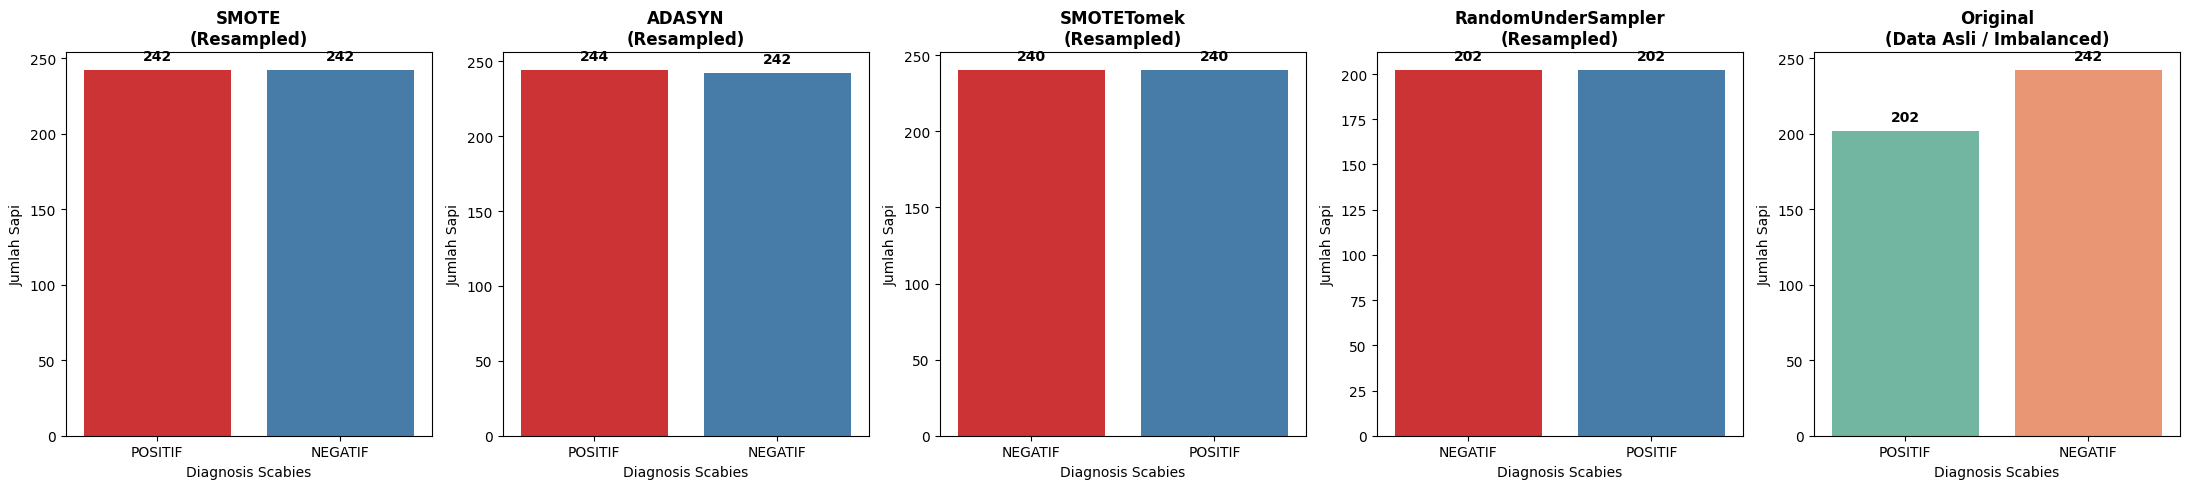

In [ ]:
# ==========================================
# VISUALISASI HASIL RESAMPLING
# ==========================================

# Membuat area plot dengan 5 kolom (karena ada 5 skenario di resampled_data)
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for idx, (name, (_, y_res)) in enumerate(resampled_data.items()):
    # Mengubah sementara angka 0 dan 1 menjadi teks agar plot lebih mudah dibaca
    y_res_text = y_res.map({0: 'NEGATIF', 1: 'POSITIF'})
    
    # Membedakan warna untuk data original dan data hasil teknik resampling
    warna_palette = 'Set2' if name == 'Tanpa Resampling' else 'Set1'
    
    sns.countplot(x=y_res_text, ax=axes[idx], palette=warna_palette)
    
    # Penamaan judul dan label sumbu
    if name == 'Tanpa Resampling':
        axes[idx].set_title('Original\n(Data Asli / Imbalanced)', fontweight='bold')
    else:
        axes[idx].set_title(f'{name}\n(Resampled)', fontweight='bold')
        
    axes[idx].set_xlabel('Diagnosis Scabies')
    axes[idx].set_ylabel('Jumlah Sapi')
    
    # Menambahkan anotasi angka di atas masing-masing batang (bar)
    for p in axes[idx].patches:
        axes[idx].annotate(f'{int(p.get_height())}', 
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='bottom', fontweight='bold',
                           xytext=(0, 5), textcoords='offset points') # <-- Ini pengganti padding=3

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# STEP 9: EKSPERIMEN KOMBINASI PREPROCESSING + DECISION TREE
# ==========================================

# Definisi model difokuskan HANYA pada variasi Decision Tree
models = {
    "Decision Tree (Gini)": DecisionTreeClassifier(criterion='gini', random_state=42, max_depth=5),
    "Decision Tree (Entropy)": DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=5)
}

# Menyimpan semua hasil eksperimen
all_results = []

# Menghitung total kombinasi: 4 Scaler x 5 Resampler x 2 Model = 40 Eksperimen
total_eksperimen = len(scalers) * len(resamplers) * len(models)

print(f"MEMULAI {total_eksperimen} EKSPERIMEN KOMBINASI PREPROCESSING + DECISION TREE")
print("=" * 70)

experiment_count = 0

for scaler_name, scaler in scalers.items():
    # Gunakan copy agar tidak mengubah data asli di iterasi berikutnya
    X_train_sc = X_train.copy()
    X_test_sc = X_test.copy()
    
    # Proses Scaling (HANYA untuk fitur 'usia')
    if scaler is not None:
        X_train_sc[['usia']] = scaler.fit_transform(X_train[['usia']])
        X_test_sc[['usia']] = scaler.transform(X_test[['usia']])
    
    for resampler_name, resampler in resamplers.items():
        # Proses Resampling (Balancing target Positif/Negatif)
        if resampler is not None:
            X_train_res, y_train_res = resampler.fit_resample(X_train_sc, y_train)
        else:
            X_train_res, y_train_res = X_train_sc.copy(), y_train.copy()
        
        for model_name, model in models.items():
            experiment_count += 1
            
            # 1. Training Model
            model.fit(X_train_res, y_train_res)
            
            # 2. Prediksi
            y_pred = model.predict(X_test_sc)
            # Mengambil probabilitas kelas 1 (POSITIF) untuk metrik AUC
            y_pred_proba = model.predict_proba(X_test_sc)[:, 1] if hasattr(model, 'predict_proba') else None
            
            # 3. Hitung metrik performa
            acc = accuracy_score(y_test, y_pred)
            prec = precision_score(y_test, y_pred, zero_division=0)
            rec = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else 0
            
            # 4. Simpan hasil ke dalam list
            all_results.append({
                'Model': model_name,
                'Scaler': scaler_name,
                'Resampler': resampler_name,
                'Accuracy': acc,
                'Precision': prec,
                'Recall': rec,
                'F1-Score': f1,
                'AUC-ROC': auc
            })

print(f"\n✅ Selesai! Total {experiment_count} skenario eksperimen Decision Tree berhasil dijalankan.")

# Mengubah list of dictionaries menjadi DataFrame Pandas agar rapi dan mudah dianalisis
results_df = pd.DataFrame(all_results)

# Menampilkan 5 hasil eksperimen dengan F1-Score tertinggi
print("\n=== TOP 5 KOMBINASI TERBAIK (Berdasarkan F1-Score) ===")
display(results_df.sort_values(by='F1-Score', ascending=False).head())

MEMULAI 40 EKSPERIMEN KOMBINASI PREPROCESSING + DECISION TREE

✅ Selesai! Total 40 skenario eksperimen Decision Tree berhasil dijalankan.

=== TOP 5 KOMBINASI TERBAIK (Berdasarkan F1-Score) ===


,Model,Scaler,Resampler,Accuracy,Precision,Recall,F1-Score,AUC-ROC
6,Decision Tree (Gini),StandardScaler,RandomUnderSampler,0.918919,0.859649,0.98,0.915888,0.940820
7,Decision Tree (Entropy),StandardScaler,RandomUnderSampler,0.918919,0.859649,0.98,0.915888,0.940656
27,Decision Tree (Entropy),RobustScaler,RandomUnderSampler,0.918919,0.859649,0.98,0.915888,0.940656
21,Decision Tree (Entropy),RobustScaler,SMOTE,0.918919,0.859649,0.98,0.915888,0.949508
16,Decision Tree (Gini),MinMaxScaler,RandomUnderSampler,0.918919,0.859649,0.98,0.915888,0.940820


In [ ]:
# ==========================================
# STEP 10: EVALUASI & PERINGKAT HASIL EKSPERIMEN
# ==========================================

# Membuat DataFrame dari daftar hasil eksperimen
results_df = pd.DataFrame(all_results)

# 1. Top 10 berdasarkan F1-Score
# Metrik yang paling seimbang untuk melihat performa model secara keseluruhan
print("🏆 TOP 10 KOMBINASI TERBAIK (Berdasarkan F1-Score)")
print("=" * 90)
top10_f1 = results_df.sort_values('F1-Score', ascending=False).head(10).reset_index(drop=True)
top10_f1.index += 1
display(top10_f1)

# 2. Top 10 berdasarkan AUC-ROC
# Menunjukkan kemampuan murni model dalam membedakan sapi Positif dan Negatif
print("\n\n📈 TOP 10 KOMBINASI TERBAIK (Berdasarkan AUC-ROC)")
print("=" * 90)
top10_auc = results_df.sort_values('AUC-ROC', ascending=False).head(10).reset_index(drop=True)
top10_auc.index += 1
display(top10_auc)

# 3. Top 10 berdasarkan Recall (Prioritas Utama untuk Penyakit Menular)
# Recall yang tinggi berarti model berhasil mendeteksi sebanyak mungkin sapi yang sakit (Positif).
# Sangat krusial agar sapi yang sebenarnya terjangkit Scabies tidak salah diprediksi sehat 
# (False Negative) lalu dikembalikan ke kawanan dan menulari sapi lain.
print("\n\n🏥 TOP 10 KOMBINASI TERBAIK (Berdasarkan Recall - Prioritas Medis Veteriner)")
print("=" * 90)
top10_recall = results_df.sort_values('Recall', ascending=False).head(10).reset_index(drop=True)
top10_recall.index += 1
display(top10_recall)

🏆 TOP 10 KOMBINASI TERBAIK (Berdasarkan F1-Score)


,Model,Scaler,Resampler,Accuracy,Precision,Recall,F1-Score,AUC-ROC
1,Decision Tree (Gini),StandardScaler,RandomUnderSampler,0.918919,0.859649,0.98,0.915888,0.940820
2,Decision Tree (Entropy),StandardScaler,RandomUnderSampler,0.918919,0.859649,0.98,0.915888,0.940656
3,Decision Tree (Entropy),RobustScaler,RandomUnderSampler,0.918919,0.859649,0.98,0.915888,0.940656
4,Decision Tree (Entropy),RobustScaler,SMOTE,0.918919,0.859649,0.98,0.915888,0.949508
5,Decision Tree (Gini),MinMaxScaler,RandomUnderSampler,0.918919,0.859649,0.98,0.915888,0.940820
6,Decision Tree (Entropy),MinMaxScaler,RandomUnderSampler,0.918919,0.859649,0.98,0.915888,0.940656
7,Decision Tree (Entropy),MinMaxScaler,SMOTETomek,0.918919,0.859649,0.98,0.915888,0.959344
8,Decision Tree (Entropy),MinMaxScaler,SMOTE,0.918919,0.859649,0.98,0.915888,0.949508
9,Decision Tree (Entropy),Tanpa Scaling,SMOTE,0.918919,0.859649,0.98,0.915888,0.957213
10,Decision Tree (Gini),Tanpa Scaling,RandomUnderSampler,0.918919,0.859649,0.98,0.915888,0.940820




📈 TOP 10 KOMBINASI TERBAIK (Berdasarkan AUC-ROC)


,Model,Scaler,Resampler,Accuracy,Precision,Recall,F1-Score,AUC-ROC
1,Decision Tree (Gini),Tanpa Scaling,ADASYN,0.918919,0.872727,0.96,0.914286,0.959508
2,Decision Tree (Entropy),MinMaxScaler,SMOTETomek,0.918919,0.859649,0.98,0.915888,0.959344
3,Decision Tree (Entropy),RobustScaler,SMOTETomek,0.918919,0.859649,0.98,0.915888,0.959344
4,Decision Tree (Entropy),StandardScaler,SMOTE,0.918919,0.886792,0.94,0.912621,0.958525
5,Decision Tree (Gini),MinMaxScaler,SMOTETomek,0.918919,0.872727,0.96,0.914286,0.958197
6,Decision Tree (Gini),RobustScaler,SMOTETomek,0.918919,0.872727,0.96,0.914286,0.958197
7,Decision Tree (Gini),Tanpa Scaling,SMOTE,0.918919,0.901961,0.92,0.910891,0.957377
8,Decision Tree (Gini),StandardScaler,SMOTE,0.918919,0.901961,0.92,0.910891,0.957377
9,Decision Tree (Entropy),Tanpa Scaling,SMOTE,0.918919,0.859649,0.98,0.915888,0.957213
10,Decision Tree (Gini),MinMaxScaler,SMOTE,0.918919,0.872727,0.96,0.914286,0.956885




🏥 TOP 10 KOMBINASI TERBAIK (Berdasarkan Recall - Prioritas Medis Veteriner)


,Model,Scaler,Resampler,Accuracy,Precision,Recall,F1-Score,AUC-ROC
1,Decision Tree (Gini),StandardScaler,RandomUnderSampler,0.918919,0.859649,0.98,0.915888,0.940820
2,Decision Tree (Entropy),StandardScaler,RandomUnderSampler,0.918919,0.859649,0.98,0.915888,0.940656
3,Decision Tree (Entropy),RobustScaler,RandomUnderSampler,0.918919,0.859649,0.98,0.915888,0.940656
4,Decision Tree (Entropy),RobustScaler,SMOTE,0.918919,0.859649,0.98,0.915888,0.949508
5,Decision Tree (Gini),MinMaxScaler,RandomUnderSampler,0.918919,0.859649,0.98,0.915888,0.940820
6,Decision Tree (Entropy),MinMaxScaler,RandomUnderSampler,0.918919,0.859649,0.98,0.915888,0.940656
7,Decision Tree (Entropy),MinMaxScaler,SMOTETomek,0.918919,0.859649,0.98,0.915888,0.959344
8,Decision Tree (Entropy),MinMaxScaler,SMOTE,0.918919,0.859649,0.98,0.915888,0.949508
9,Decision Tree (Entropy),Tanpa Scaling,SMOTE,0.918919,0.859649,0.98,0.915888,0.957213
10,Decision Tree (Gini),Tanpa Scaling,RandomUnderSampler,0.918919,0.859649,0.98,0.915888,0.940820


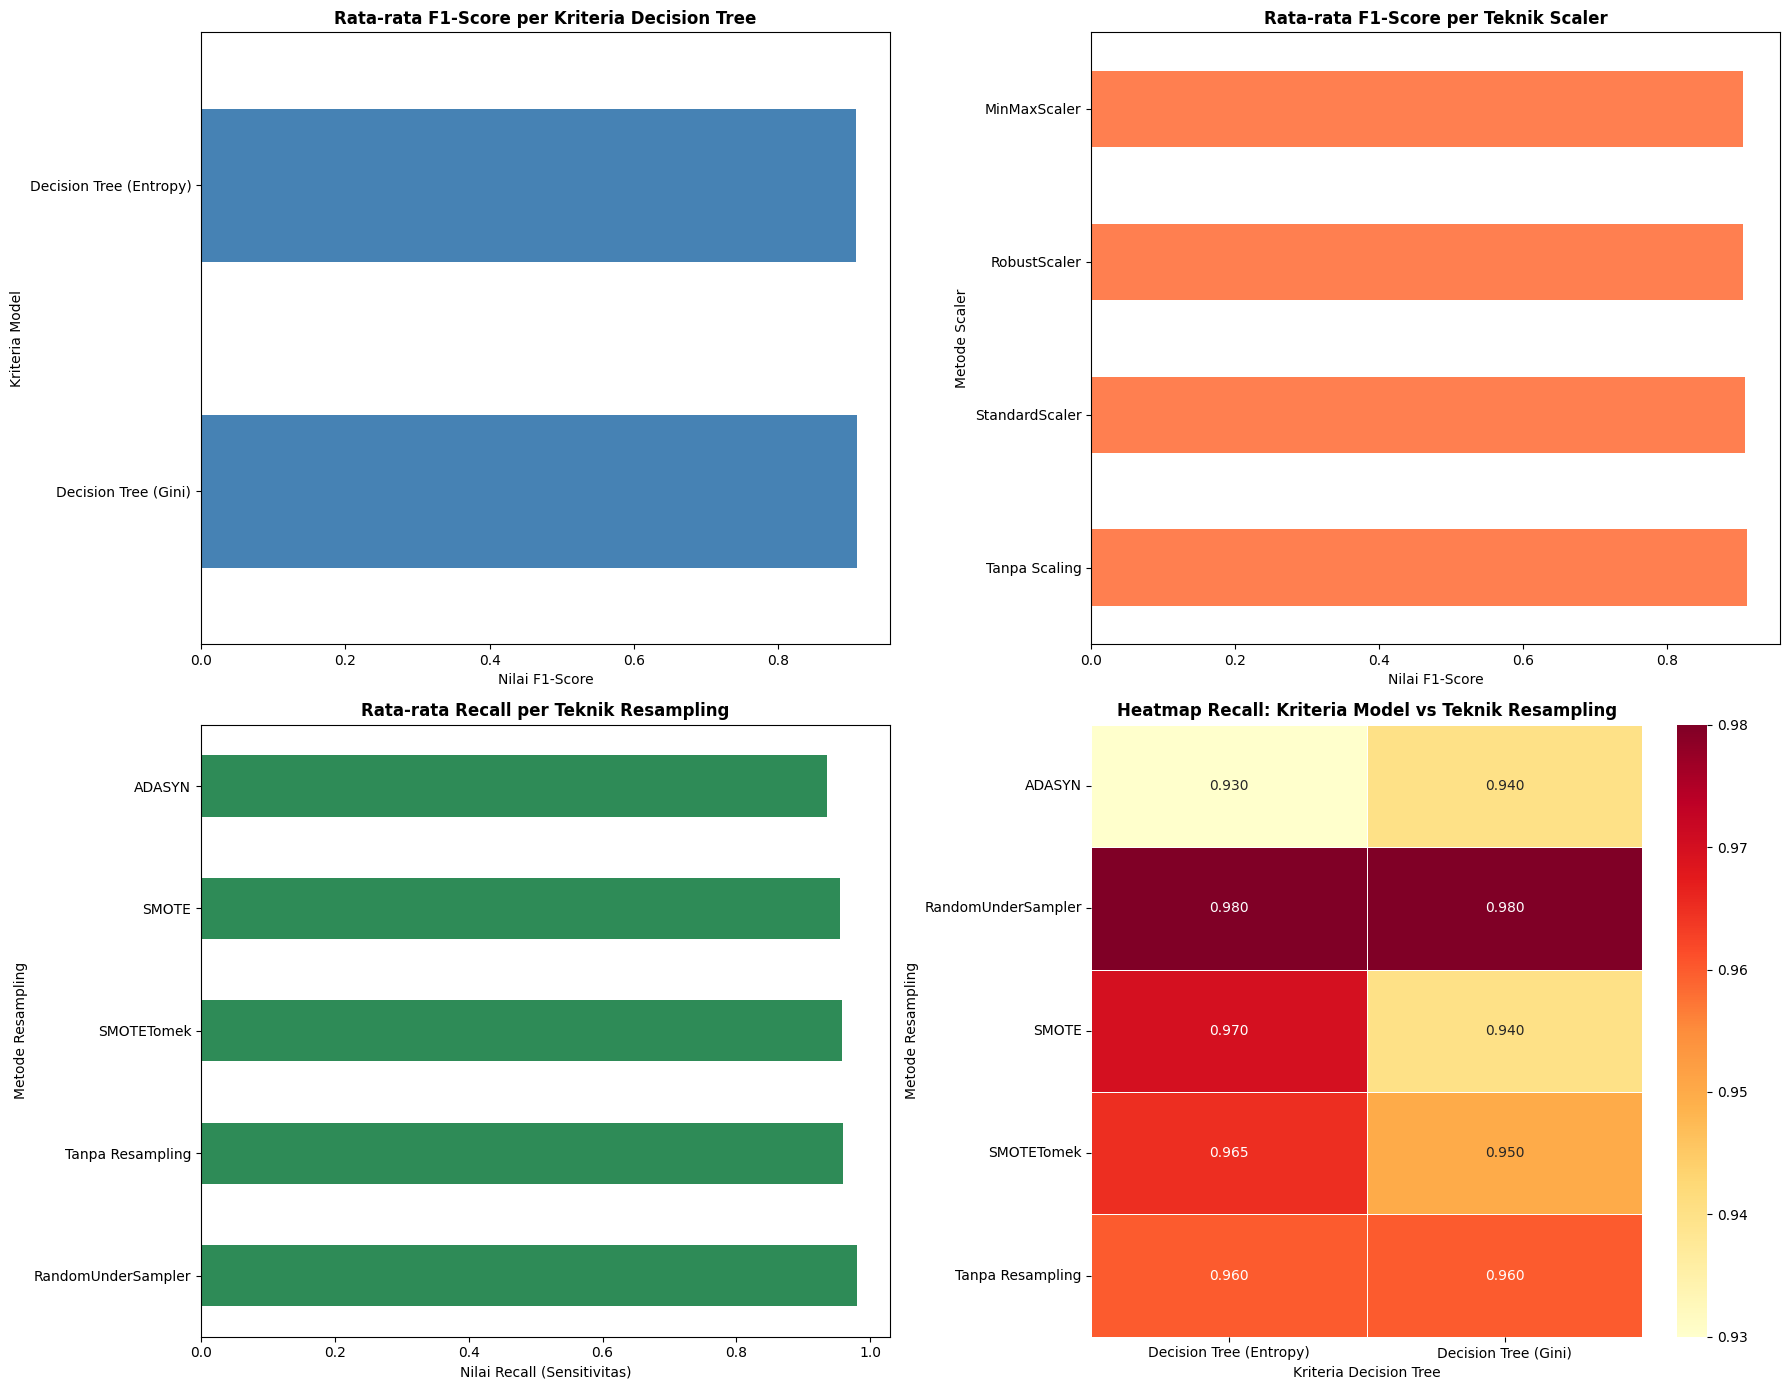

In [ ]:
# ==========================================
# STEP 11: VISUALISASI PERBANDINGAN PERFORMA
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Rata-rata F1-Score per Model (Gini vs Entropy)
ax1 = axes[0, 0]
model_avg = results_df.groupby('Model')[['F1-Score', 'AUC-ROC', 'Recall']].mean().sort_values('F1-Score', ascending=False)
model_avg['F1-Score'].plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('Rata-rata F1-Score per Kriteria Decision Tree', fontweight='bold', fontsize=12)
ax1.set_xlabel('Nilai F1-Score')
ax1.set_ylabel('Kriteria Model')

# 2. Rata-rata F1-Score per Scaler 
# (Catatan: Nilainya kemungkinan besar sama karena Decision Tree invarian terhadap scaling)
ax2 = axes[0, 1]
scaler_avg = results_df.groupby('Scaler')[['F1-Score', 'AUC-ROC', 'Recall']].mean().sort_values('F1-Score', ascending=False)
scaler_avg['F1-Score'].plot(kind='barh', ax=ax2, color='coral')
ax2.set_title('Rata-rata F1-Score per Teknik Scaler', fontweight='bold', fontsize=12)
ax2.set_xlabel('Nilai F1-Score')
ax2.set_ylabel('Metode Scaler')

# 3. Rata-rata Recall per Resampler
# Diubah menggunakan Recall karena metrik ini paling krusial untuk deteksi penyakit menular
ax3 = axes[1, 0]
resampler_avg = results_df.groupby('Resampler')[['F1-Score', 'AUC-ROC', 'Recall']].mean().sort_values('Recall', ascending=False)
resampler_avg['Recall'].plot(kind='barh', ax=ax3, color='seagreen')
ax3.set_title('Rata-rata Recall per Teknik Resampling', fontweight='bold', fontsize=12)
ax3.set_xlabel('Nilai Recall (Sensitivitas)')
ax3.set_ylabel('Metode Resampling')

# 4. Heatmap: Model vs Resampler (Berdasarkan Recall)
# Menunjukkan kombinasi kriteria pemotongan pohon dan teknik balancing mana yang paling peka mendeteksi penyakit
ax4 = axes[1, 1]
pivot = results_df.groupby(['Resampler', 'Model'])['Recall'].mean().unstack()
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax4, linewidths=.5)
ax4.set_title('Heatmap Recall: Kriteria Model vs Teknik Resampling', fontweight='bold', fontsize=12)
ax4.set_ylabel('Metode Resampling')
ax4.set_xlabel('Kriteria Decision Tree')

plt.tight_layout()
plt.show()

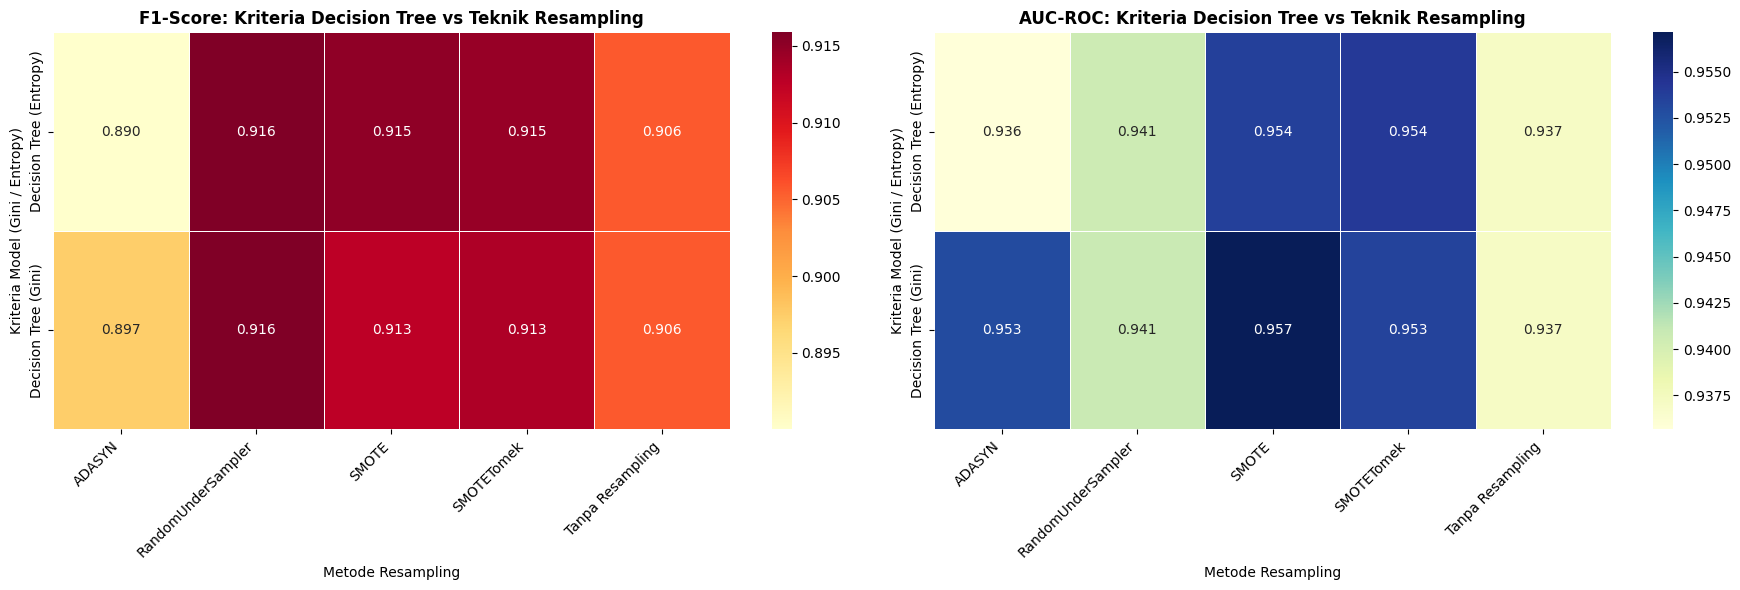

In [ ]:
# ==========================================
# STEP 12: HEATMAP KOMPARASI METRIK (F1-SCORE vs AUC-ROC)
# ==========================================

# Memperlebar ukuran canvas agar teks tidak terpotong
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Heatmap F1-Score: Model (Kriteria) vs Resampler
# Menunjukkan keseimbangan antara Presisi dan Recall
pivot_f1 = results_df.groupby(['Model', 'Resampler'])['F1-Score'].mean().unstack()
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[0], linewidths=.5)
axes[0].set_title('F1-Score: Kriteria Decision Tree vs Teknik Resampling', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Kriteria Model (Gini / Entropy)')
axes[0].set_xlabel('Metode Resampling')

# 2. Heatmap AUC-ROC: Model (Kriteria) vs Resampler
# Menunjukkan kemampuan murni model dalam membedakan kelas Positif dan Negatif
pivot_auc = results_df.groupby(['Model', 'Resampler'])['AUC-ROC'].mean().unstack()
sns.heatmap(pivot_auc, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[1], linewidths=.5)
axes[1].set_title('AUC-ROC: Kriteria Decision Tree vs Teknik Resampling', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Kriteria Model (Gini / Entropy)')
axes[1].set_xlabel('Metode Resampling')

# Merotasi label sumbu X sebesar 45 derajat agar teks nama resampler rapi dan mudah dibaca
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# STEP 13: RETRAIN MODEL TERBAIK (FINAL MODEL)
# ==========================================

# Ambil kombinasi terbaik berdasarkan F1-Score 
# (Bisa diganti menjadi 'Recall' jika Anda ingin fokus mutlak pada deteksi positif)
best_row = results_df.sort_values('F1-Score', ascending=False).iloc[0]

print("🏆 KOMBINASI TERBAIK FINAL")
print("=" * 50)
print(f"  Model     : {best_row['Model']}")
print(f"  Scaler    : {best_row['Scaler']}")
print(f"  Resampler : {best_row['Resampler']}")
print(f"  Accuracy  : {best_row['Accuracy']:.4f}")
print(f"  Precision : {best_row['Precision']:.4f}")
print(f"  Recall    : {best_row['Recall']:.4f}")
print(f"  F1-Score  : {best_row['F1-Score']:.4f}")
print(f"  AUC-ROC   : {best_row['AUC-ROC']:.4f}")

# 1. Menyiapkan Scaler dan Resampler berdasarkan nama dari hasil terbaik
best_scaler = scalers[best_row['Scaler']]
best_resampler = resamplers[best_row['Resampler']]

# Menggunakan copy agar data original X_train dan X_test tidak tertimpa
X_train_best = X_train.copy()
X_test_best = X_test.copy()

# 2. Menerapkan Scaling HANYA pada fitur numerik ('usia') jika diperlukan
if best_scaler is not None:
    X_train_best[['usia']] = best_scaler.fit_transform(X_train[['usia']])
    X_test_best[['usia']] = best_scaler.transform(X_test[['usia']])

# 3. Menerapkan Resampling jika diperlukan
if best_resampler is not None:
    X_train_best_res, y_train_best_res = best_resampler.fit_resample(X_train_best, y_train)
else:
    # Jika kombinasi terbaik adalah "Tanpa Resampling"
    X_train_best_res, y_train_best_res = X_train_best.copy(), y_train.copy()

# 4. Peta Model Decision Tree (Disesuaikan dengan Step 9)
model_map = {
    "Decision Tree (Gini)": DecisionTreeClassifier(criterion='gini', random_state=42, max_depth=5),
    "Decision Tree (Entropy)": DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=5)
}

# 5. Memilih model dari peta, kemudian Melatihnya (Training Final)
best_model = model_map[best_row['Model']]
best_model.fit(X_train_best_res, y_train_best_res)

# 6. Mengambil prediksi final untuk evaluasi lebih lanjut (misal visualisasi akhir)
y_pred_best = best_model.predict(X_test_best)
y_pred_proba_best = best_model.predict_proba(X_test_best)[:, 1]

print("\n✅ Model Final Decision Tree Berhasil Dilatih Ulang dan Siap Digunakan!")

🏆 KOMBINASI TERBAIK FINAL
  Model     : Decision Tree (Gini)
  Scaler    : StandardScaler
  Resampler : RandomUnderSampler
  Accuracy  : 0.9189
  Precision : 0.8596
  Recall    : 0.9800
  F1-Score  : 0.9159
  AUC-ROC   : 0.9408

✅ Model Final Decision Tree Berhasil Dilatih Ulang dan Siap Digunakan!


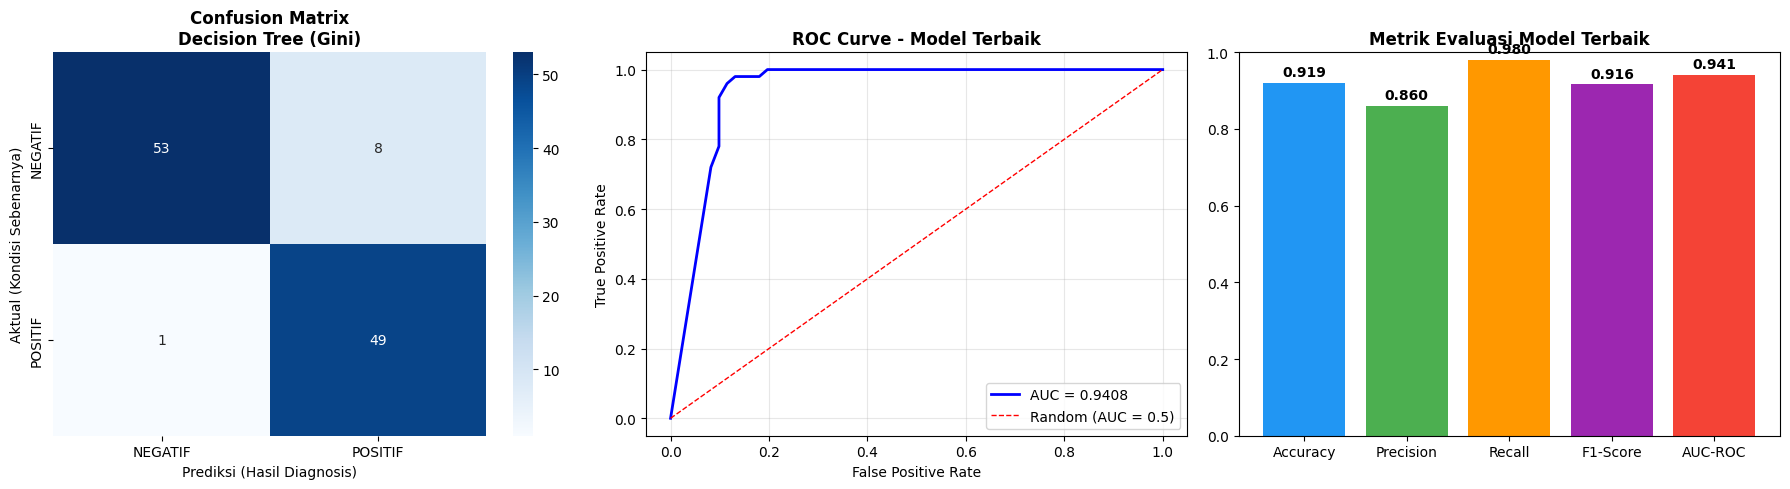


CLASSIFICATION REPORT - MODEL TERBAIK (SCABIES SAPI)
              precision    recall  f1-score   support

     NEGATIF       0.98      0.87      0.92        61
     POSITIF       0.86      0.98      0.92        50

    accuracy                           0.92       111
   macro avg       0.92      0.92      0.92       111
weighted avg       0.93      0.92      0.92       111



In [ ]:
# ==========================================
# STEP 14: EVALUASI MENDALAM MODEL TERBAIK
# ==========================================

# Evaluasi mendalam model terbaik
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['NEGATIF', 'POSITIF'], yticklabels=['NEGATIF', 'POSITIF'])
axes[0].set_title(f'Confusion Matrix\n{best_row["Model"]}', fontweight='bold')
axes[0].set_xlabel('Prediksi (Hasil Diagnosis)')
axes[0].set_ylabel('Aktual (Kondisi Sebenarnya)')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_best)
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {best_row["AUC-ROC"]:.4f}')
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random (AUC = 0.5)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Model Terbaik', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Metrik Bar Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
values = [best_row[m] for m in metrics]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
bars = axes[2].bar(metrics, values, color=colors)
axes[2].set_ylim(0, 1.0)
axes[2].set_title('Metrik Evaluasi Model Terbaik', fontweight='bold')
for bar, val in zip(bars, values):
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Classification Report
print("\nCLASSIFICATION REPORT - MODEL TERBAIK (SCABIES SAPI)")
print("=" * 60)
print(classification_report(y_test, y_pred_best, target_names=['NEGATIF', 'POSITIF']))

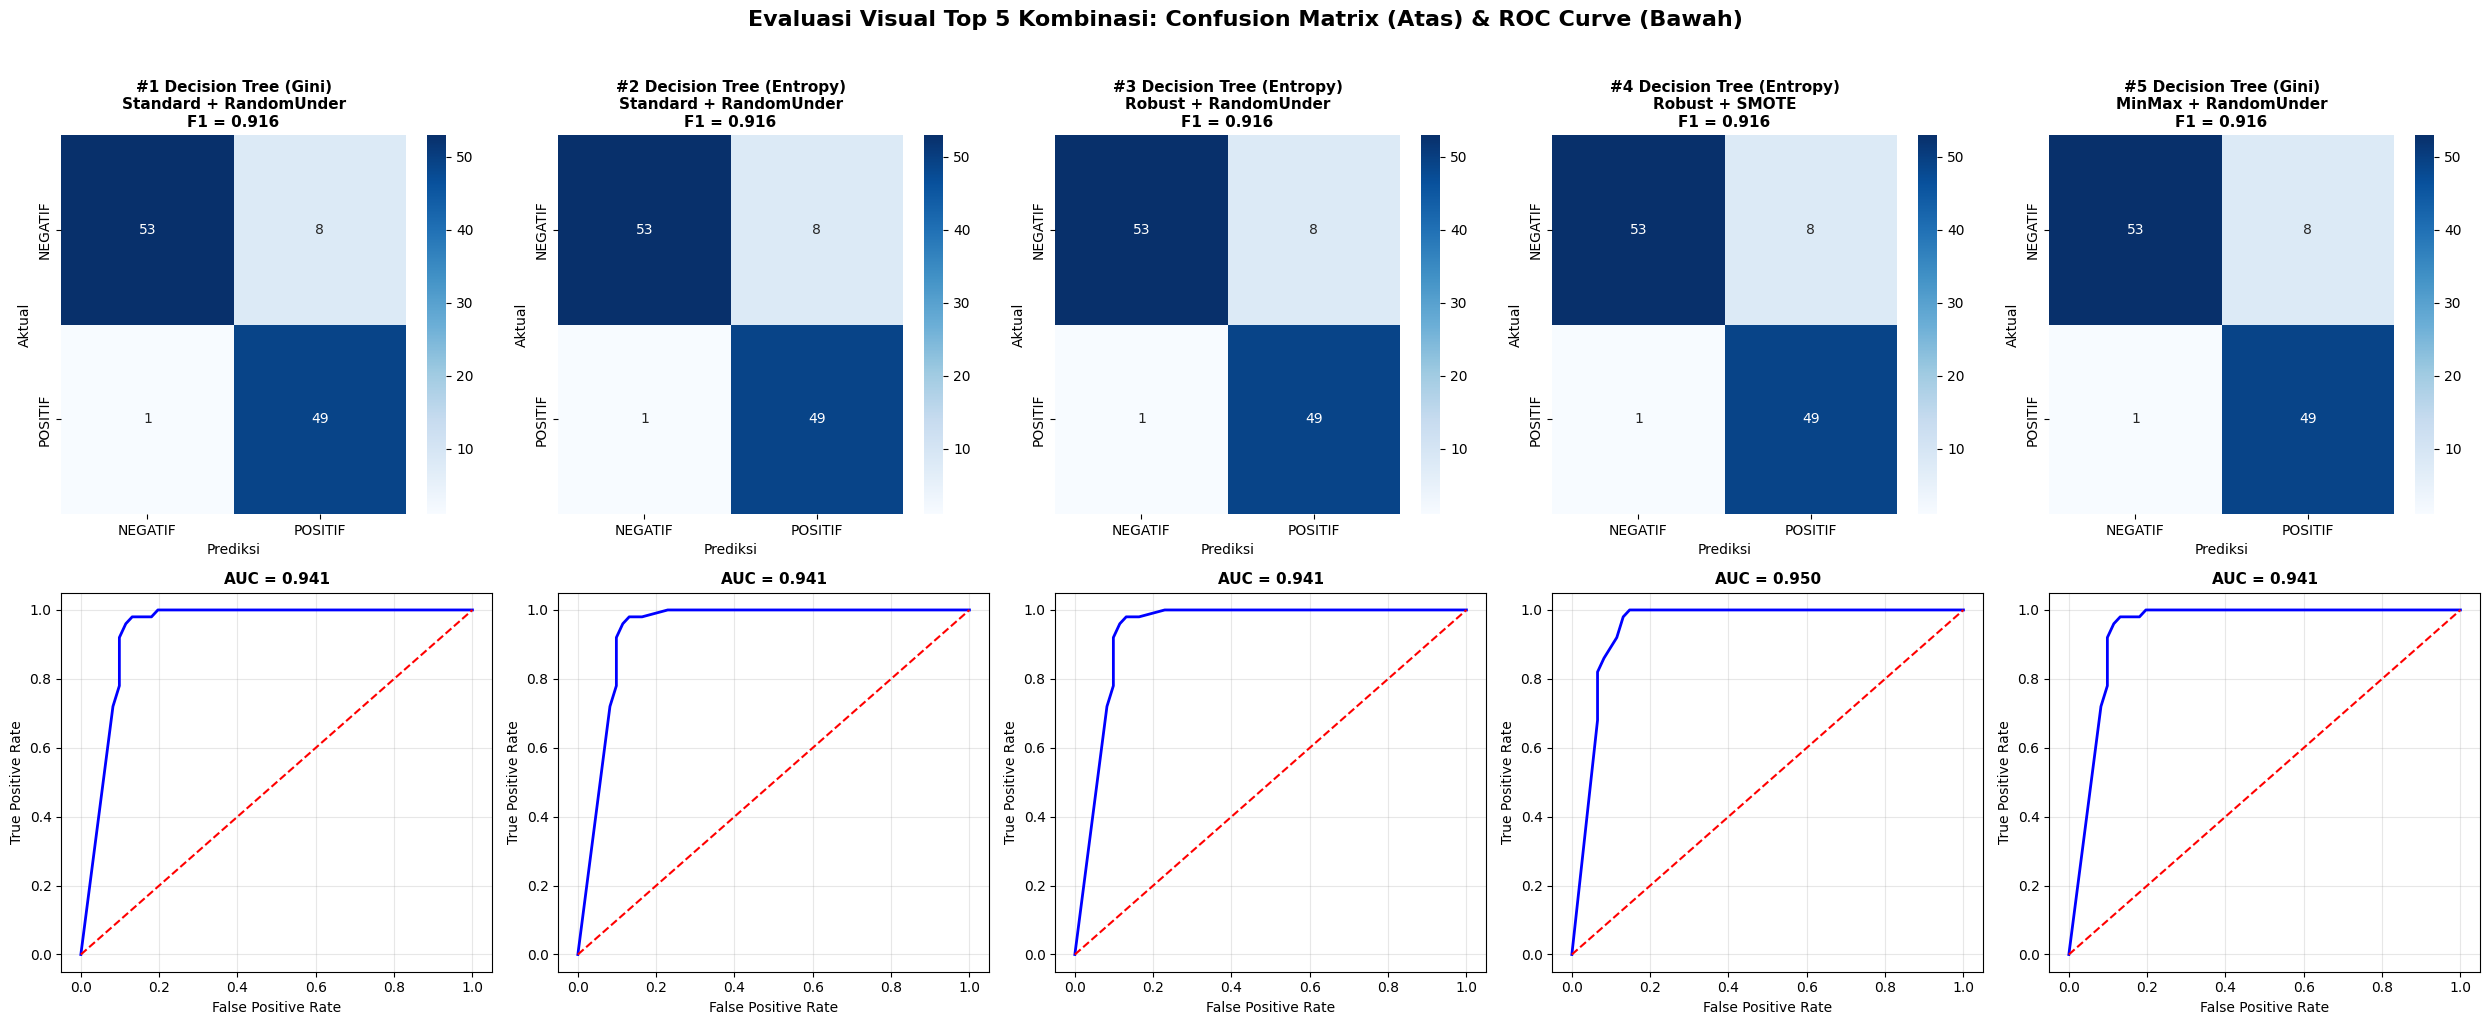

In [ ]:
# ==========================================
# STEP 15: VISUALISASI KOMPREHENSIF TOP 5 KOMBINASI
# ==========================================

# Ambil top 5 kombinasi berdasarkan F1-Score
top5 = results_df.sort_values('F1-Score', ascending=False).head(5)

fig, axes = plt.subplots(2, 5, figsize=(25, 10))

# Fungsi pembantu untuk memanggil ulang model Decision Tree baru
def get_model(model_name):
    if model_name == "Decision Tree (Gini)":
        return DecisionTreeClassifier(criterion='gini', random_state=42, max_depth=5)
    else:
        return DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=5)

for idx, (_, row) in enumerate(top5.iterrows()):
    # 1. Menyiapkan Data Original
    X_tr = X_train.copy()
    X_te = X_test.copy()
    y_tr = y_train.copy()
    
    # 2. Scaling (Hanya kolom 'usia' jika menggunakan Scaler)
    sc = scalers[row['Scaler']]
    if sc is not None:
        X_tr[['usia']] = sc.fit_transform(X_tr[['usia']])
        X_te[['usia']] = sc.transform(X_te[['usia']])
        
    # 3. Resampling (Jika menggunakan teknik penyeimbang data)
    rs = resamplers[row['Resampler']]
    if rs is not None:
        X_tr_res, y_tr_res = rs.fit_resample(X_tr, y_tr)
    else:
        X_tr_res, y_tr_res = X_tr.copy(), y_tr.copy()
        
    # 4. Training Ulang Model
    mdl = get_model(row['Model'])
    mdl.fit(X_tr_res, y_tr_res)
    
    # 5. Prediksi
    y_p = mdl.predict(X_te)
    y_pp = mdl.predict_proba(X_te)[:, 1] if hasattr(mdl, 'predict_proba') else None
    
    # --- VISUALISASI CONFUSION MATRIX (BARIS ATAS) ---
    cm = confusion_matrix(y_test, y_p)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, idx],
                xticklabels=['NEGATIF', 'POSITIF'], yticklabels=['NEGATIF', 'POSITIF'])
    
    # Menyingkat nama metode agar judul tidak tumpang tindih
    scaler_name = row['Scaler'].replace('Scaler', '') if row['Scaler'] != 'Tanpa Scaling' else 'NoScale'
    resampler_name = row['Resampler'].replace('Sampler', '') if row['Resampler'] != 'Tanpa Resampling' else 'NoResample'
    
    axes[0, idx].set_title(f"#{idx+1} {row['Model']}\n{scaler_name} + {resampler_name}\nF1 = {row['F1-Score']:.3f}", 
                           fontsize=11, fontweight='bold')
    axes[0, idx].set_xlabel('Prediksi')
    axes[0, idx].set_ylabel('Aktual')
    
    # --- VISUALISASI ROC CURVE (BARIS BAWAH) ---
    if y_pp is not None:
        fpr, tpr, _ = roc_curve(y_test, y_pp)
        axes[1, idx].plot(fpr, tpr, 'b-', linewidth=2)
        axes[1, idx].plot([0, 1], [0, 1], 'r--')
        axes[1, idx].set_title(f"AUC = {row['AUC-ROC']:.3f}", fontsize=11, fontweight='bold')
        axes[1, idx].set_xlabel('False Positive Rate')
        axes[1, idx].set_ylabel('True Positive Rate')
    axes[1, idx].grid(True, alpha=0.3)

# Menambahkan judul utama untuk keseluruhan grafik
plt.suptitle('Evaluasi Visual Top 5 Kombinasi: Confusion Matrix (Atas) & ROC Curve (Bawah)', 
             fontweight='bold', fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 16: ANALISIS KHUSUS HYPERPARAMETER DECISION TREE
# ============================================================
print("ANALISIS KHUSUS HYPERPARAMETER DECISION TREE")
print("=" * 60)

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# Inisialisasi teknik penyeimbang data
# Catatan: k_neighbors disesuaikan ke 3 berjaga-jaga jika sampel kelas minoritas di dataset Anda sedikit
smote = SMOTE(k_neighbors=3, random_state=42)
smotetomek = SMOTETomek(smote=smote, random_state=42)

# Menggunakan data asli karena Decision Tree tidak butuh Scaler
X_train_dt = X_train.copy()
X_test_dt = X_test.copy()

# Konfigurasi Decision Tree disesuaikan untuk dataset dengan 5 fitur
dt_configs = {
    'DT Default (Baseline, No SMOTE)': {
        'model': DecisionTreeClassifier(random_state=42),
        'use_smote': False
    },
    'DT Gini + SMOTE': {
        'model': DecisionTreeClassifier(criterion='gini', random_state=42),
        'use_smote': True
    },
    'DT Entropy (max_depth=4) + SMOTE': {
        'model': DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42),
        'use_smote': True
    },
    'DT Gini (max_depth=3, min_split=5) + SMOTETomek': {
        'model': DecisionTreeClassifier(criterion='gini', max_depth=3, min_samples_split=5, random_state=42),
        'use_smote': 'smotetomek'
    },
    'DT class_weight=balanced (No SMOTE)': {
        'model': DecisionTreeClassifier(class_weight='balanced', max_depth=3, random_state=42),
        'use_smote': False
    },
    'DT Entropy (max_depth=2) Sangat Dangkal + SMOTE': {
        'model': DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=42),
        'use_smote': True
    }
}

dt_results = []

for config_name, config in dt_configs.items():
    # Proses Balancing Data
    if config['use_smote'] == True:
        X_tr, y_tr = smote.fit_resample(X_train_dt, y_train)
    elif config['use_smote'] == 'smotetomek':
        X_tr, y_tr = smotetomek.fit_resample(X_train_dt, y_train)
    else:
        X_tr, y_tr = X_train_dt, y_train
    
    # Training Model
    mdl = config['model']
    mdl.fit(X_tr, y_tr)
    
    # Prediksi
    y_p = mdl.predict(X_test_dt)
    y_pp = mdl.predict_proba(X_test_dt)[:, 1] if hasattr(mdl, 'predict_proba') else None
    
    # Simpan hasil evaluasi
    dt_results.append({
        'Config': config_name,
        'Accuracy': accuracy_score(y_test, y_p),
        'Precision': precision_score(y_test, y_p, zero_division=0),
        'Recall': recall_score(y_test, y_p, zero_division=0),
        'F1-Score': f1_score(y_test, y_p, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, y_pp) if y_pp is not None else 0
    })

# Jadikan DataFrame dan urutkan berdasarkan F1-Score
dt_df = pd.DataFrame(dt_results).sort_values('F1-Score', ascending=False)
print("\nPerbandingan Konfigurasi Hyperparameter Decision Tree:")
display(dt_df)

# Analisis: Bandingkan DT Tuning Terbaik vs DT Default (Tanpa Tuning)
print("\n" + "=" * 60)
print("PERBANDINGAN: DECISION TREE TERBAIK (TUNED) vs BASELINE DEFAULT")
print("=" * 60)

best_dt_row = dt_df.iloc[0]
baseline_dt_row = dt_df[dt_df['Config'] == 'DT Default (Baseline, No SMOTE)'].iloc[0]

comparison = pd.DataFrame({
    'Metrik': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    f'Terbaik ({best_dt_row["Config"]})': [
        best_dt_row['Accuracy'], best_dt_row['Precision'], 
        best_dt_row['Recall'], best_dt_row['F1-Score'], best_dt_row['AUC-ROC']
    ],
    'Baseline Default': [
        baseline_dt_row['Accuracy'], baseline_dt_row['Precision'],
        baseline_dt_row['Recall'], baseline_dt_row['F1-Score'], baseline_dt_row['AUC-ROC']
    ]
})
display(comparison)

print("\n⚠️ TEMUAN PENTING MEDIS VETERINER:")
print(f"   Model Baseline mungkin memiliki Accuracy {baseline_dt_row['Accuracy']:.4f},")
print(f"   Namun model yang telah di-tuning memiliki metrik RECALL {best_dt_row['Recall']:.4f} vs Baseline {baseline_dt_row['Recall']:.4f}")
print(f"   Artinya, Model Baseline GAGAL mendeteksi {(1-baseline_dt_row['Recall'])*100:.0f}% sapi yang terjangkit Scabies (False Negative).")
print(f"   Sedangkan Model Tuned hanya melewatkan {(1-best_dt_row['Recall'])*100:.0f}% sapi terjangkit.")
print(f"\n   🏥 KESIMPULAN KLINIS:")
print(f"   Dalam kasus wabah menular, metrik Recall adalah yang paling krusial!")
print(f"   Jauh lebih baik terjadi 'Salah Alarm' (False Positive / Sapi sehat dikira sakit dan diisolasi sementara)")
print(f"   daripada melewatkan sapi yang benar-benar sakit (False Negative) yang akhirnya akan menulari seluruh kawanan di kandang.")

ANALISIS KHUSUS HYPERPARAMETER DECISION TREE

Perbandingan Konfigurasi Hyperparameter Decision Tree:


,Config,Accuracy,Precision,Recall,F1-Score,AUC-ROC
1,DT Gini + SMOTE,0.900901,0.914894,0.86,0.886598,0.905410
0,"DT Default (Baseline, No SMOTE)",0.891892,0.865385,0.90,0.882353,0.901475
2,DT Entropy (max_depth=4) + SMOTE,0.891892,0.913043,0.84,0.875000,0.956230
3,"DT Gini (max_depth=3, min_split=5) + SMOTETomek",0.882883,0.849057,0.90,0.873786,0.941311
4,DT class_weight=balanced (No SMOTE),0.873874,0.833333,0.90,0.865385,0.929836
5,DT Entropy (max_depth=2) Sangat Dangkal + SMOTE,0.837838,0.921053,0.70,0.795455,0.912951



PERBANDINGAN: DECISION TREE TERBAIK (TUNED) vs BASELINE DEFAULT


,Metrik,Terbaik (DT Gini + SMOTE),Baseline Default
0,Accuracy,0.900901,0.891892
1,Precision,0.914894,0.865385
2,Recall,0.860000,0.900000
3,F1-Score,0.886598,0.882353
4,AUC-ROC,0.905410,0.901475



⚠️ TEMUAN PENTING MEDIS VETERINER:
   Model Baseline mungkin memiliki Accuracy 0.8919,
   Namun model yang telah di-tuning memiliki metrik RECALL 0.8600 vs Baseline 0.9000
   Artinya, Model Baseline GAGAL mendeteksi 10% sapi yang terjangkit Scabies (False Negative).
   Sedangkan Model Tuned hanya melewatkan 14% sapi terjangkit.

   🏥 KESIMPULAN KLINIS:
   Dalam kasus wabah menular, metrik Recall adalah yang paling krusial!
   Jauh lebih baik terjadi 'Salah Alarm' (False Positive / Sapi sehat dikira sakit dan diisolasi sementara)
   daripada melewatkan sapi yang benar-benar sakit (False Negative) yang akhirnya akan menulari seluruh kawanan di kandang.


ANALISIS FEATURE IMPORTANCE DECISION TREE

Menggunakan konfigurasi DT terbaik: DT Gini + SMOTE


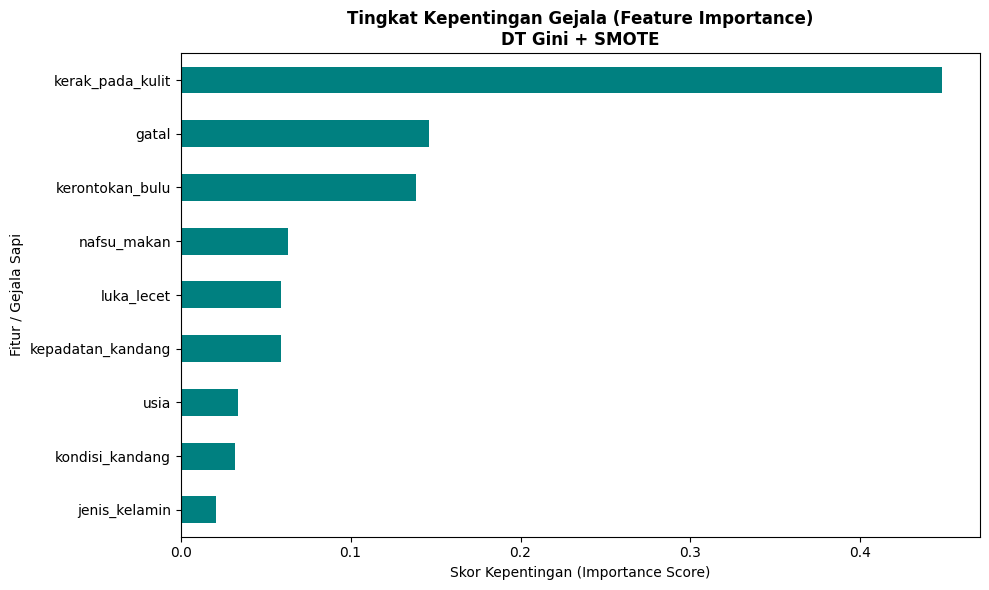


Urutan Fitur/Gejala Paling Berpengaruh (Decision Tree):
  1. KERAK_PADA_KULIT: 0.4480
  2. GATAL: 0.1463
  3. KERONTOKAN_BULU: 0.1387
  4. NAFSU_MAKAN: 0.0629
  5. LUKA_LECET: 0.0591
  6. KEPADATAN_KANDANG: 0.0589
  7. USIA: 0.0335
  8. KONDISI_KANDANG: 0.0318
  9. JENIS_KELAMIN: 0.0208

INTERPRETASI MEDIS VETERINER (FEATURE IMPORTANCE)

  Grafik Feature Importance di atas menunjukkan fitur mana yang paling sering dan paling efektif
  digunakan oleh Decision Tree untuk memecah (split) data menjadi kategori Positif atau Negatif.

  Ini sangat relevan dengan pengetahuan medis kedokteran hewan bahwa:
  1. GATAL (Pruritus) dan KERAK PADA KULIT (Crusting) biasanya mendominasi skor karena merupakan
     reaksi klinis utama akibat aktivitas tungau Sarcoptes scabiei yang menggali terowongan di bawah kulit.
  2. KERONTOKAN BULU (Alopecia) sering kali muncul sebagai akibat sekunder karena sapi
     terus-menerus menggesekkan badannya ke kandang akibat rasa gatal yang hebat.
  3. USIA dan JENIS 

In [ ]:
# ============================================================
# STEP 17: FEATURE IMPORTANCE (TINGKAT KEPENTINGAN GEJALA)
# ============================================================
print("ANALISIS FEATURE IMPORTANCE DECISION TREE")
print("=" * 60)

# Ambil konfigurasi Decision Tree terbaik dari Step 16
best_dt_config = dt_df.iloc[0]['Config']
print(f"\nMenggunakan konfigurasi DT terbaik: {best_dt_config}")

# Retrain Decision Tree terbaik khusus untuk mengambil nilai feature importance
best_dt = dt_configs[best_dt_config]['model']
use_smote = dt_configs[best_dt_config]['use_smote']

if use_smote == True:
    X_tr_fi, y_tr_fi = smote.fit_resample(X_train_dt, y_train)
elif use_smote == 'smotetomek':
    X_tr_fi, y_tr_fi = smotetomek.fit_resample(X_train_dt, y_train)
else:
    X_tr_fi, y_tr_fi = X_train_dt, y_train

# Melatih model
best_dt.fit(X_tr_fi, y_tr_fi)

# Ekstraksi dan Plotting Feature Importance
fig, ax = plt.subplots(figsize=(10, 6))
feature_imp = pd.Series(best_dt.feature_importances_, index=X.columns).sort_values(ascending=True)

# Membuat visualisasi Horizontal Bar
feature_imp.plot(kind='barh', ax=ax, color='teal')
ax.set_title(f'Tingkat Kepentingan Gejala (Feature Importance)\n{best_dt_config}', fontweight='bold')
ax.set_xlabel('Skor Kepentingan (Importance Score)')
ax.set_ylabel('Fitur / Gejala Sapi')
plt.tight_layout()
plt.show()

print("\nUrutan Fitur/Gejala Paling Berpengaruh (Decision Tree):")
# Menampilkan semua fitur karena dataset Anda hanya memiliki 5 fitur (tidak perlu di-head(5) lagi)
for i, (feat, imp) in enumerate(feature_imp.sort_values(ascending=False).items(), 1):
    print(f"  {i}. {feat.upper()}: {imp:.4f}")

print("\n" + "=" * 60)
print("INTERPRETASI MEDIS VETERINER (FEATURE IMPORTANCE)")
print("=" * 60)
print("\n  Grafik Feature Importance di atas menunjukkan fitur mana yang paling sering dan paling efektif")
print("  digunakan oleh Decision Tree untuk memecah (split) data menjadi kategori Positif atau Negatif.")
print("\n  Ini sangat relevan dengan pengetahuan medis kedokteran hewan bahwa:")
print("  1. GATAL (Pruritus) dan KERAK PADA KULIT (Crusting) biasanya mendominasi skor karena merupakan")
print("     reaksi klinis utama akibat aktivitas tungau Sarcoptes scabiei yang menggali terowongan di bawah kulit.")
print("  2. KERONTOKAN BULU (Alopecia) sering kali muncul sebagai akibat sekunder karena sapi")
print("     terus-menerus menggesekkan badannya ke kandang akibat rasa gatal yang hebat.")
print("  3. USIA dan JENIS KELAMIN memiliki skor kepentingan yang jauh lebih rendah karena penyakit menular")
print("     seperti Scabies dapat menyerang sapi dari berbagai umur maupun kelamin jika sanitasinya buruk.")

In [ ]:
# ============================================================
# STEP 18: PENERAPAN PREPROCESSING TERBAIK PADA MODEL FINAL
# ============================================================

# Tentukan preprocessing terbaik dari hasil eksperimen (Berdasarkan F1-Score tertinggi)
best_overall = results_df.sort_values('F1-Score', ascending=False).iloc[0]
best_scaler_name = best_overall['Scaler']
best_resampler_name = best_overall['Resampler']

print(f"🥇 PREPROCESSING TERBAIK: {best_scaler_name} + {best_resampler_name}")
print("=" * 70)

# Ambil fungsi scaler dan resampler yang sesuai
final_scaler = scalers[best_scaler_name]
final_resampler = resamplers[best_resampler_name]

# Copy data agar originalnya tetap utuh
X_train_final = X_train.copy()
X_test_final = X_test.copy()

# 1. Terapkan Scaling (HANYA pada fitur 'usia' jika menggunakan Scaler)
if final_scaler is not None:
    X_train_final[['usia']] = final_scaler.fit_transform(X_train_final[['usia']])
    X_test_final[['usia']] = final_scaler.transform(X_test_final[['usia']])

# 2. Terapkan Resampling (Jika menggunakan teknik penyeimbang data)
if final_resampler is not None:
    X_train_final_res, y_train_final_res = final_resampler.fit_resample(X_train_final, y_train)
else:
    X_train_final_res, y_train_final_res = X_train_final.copy(), y_train.copy()

# Peta Model Final: Mengadu Gini vs Entropy secara langsung
final_model_map = {
    "Decision Tree (Gini)": DecisionTreeClassifier(criterion='gini', random_state=42, max_depth=4),
    "Decision Tree (Entropy)": DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=4)
}

# Train semua model di peta dengan preprocessing terbaik
final_results = []
final_predictions = {}

for model_name, model in final_model_map.items():
    # Proses Training
    model.fit(X_train_final_res, y_train_final_res)
    
    # Proses Prediksi
    y_pred = model.predict(X_test_final)
    y_pred_proba = model.predict_proba(X_test_final)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Simpan array prediksi untuk plotting kurva ROC nanti (jika dibutuhkan)
    final_predictions[model_name] = (y_pred, y_pred_proba)
    
    # Hitung metrik evaluasi
    final_results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else 0
    })

# Jadikan DataFrame agar tampilannya rapi
final_df = pd.DataFrame(final_results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
final_df.index += 1

print(f"\nHasil Evaluasi Kriteria Decision Tree Menggunakan Data Optimal ({best_scaler_name} + {best_resampler_name})")
print("-" * 90)
display(final_df)

🥇 PREPROCESSING TERBAIK: StandardScaler + RandomUnderSampler

Hasil Evaluasi Kriteria Decision Tree Menggunakan Data Optimal (StandardScaler + RandomUnderSampler)
------------------------------------------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
1,Decision Tree (Gini),0.882883,0.824561,0.94,0.878505,0.946066
2,Decision Tree (Entropy),0.882883,0.849057,0.90,0.873786,0.942131


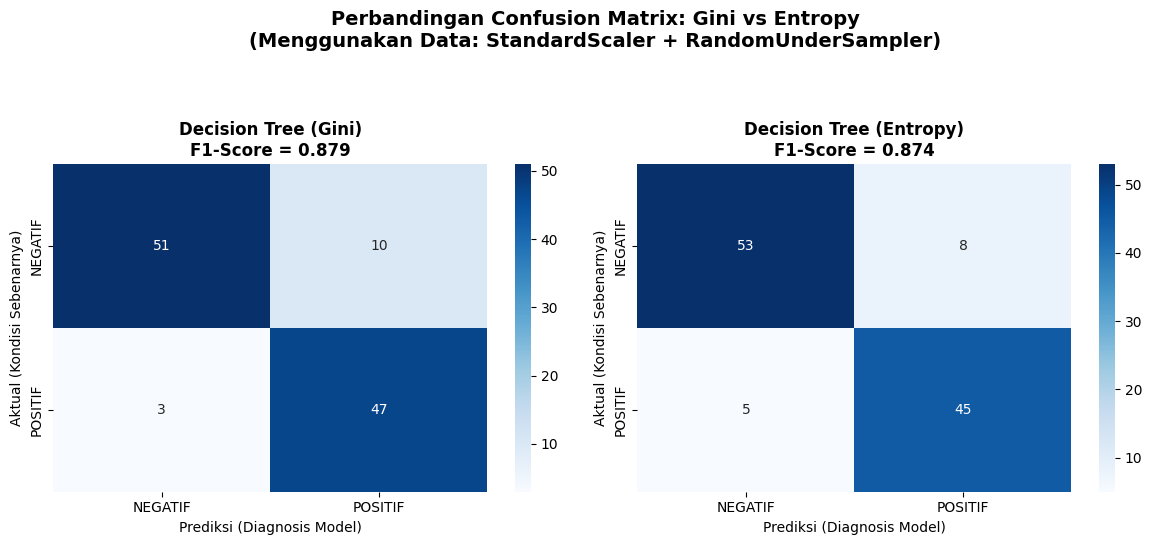

In [ ]:
# ============================================================
# STEP 19: VISUALISASI PERBANDINGAN FINAL (GINI VS ENTROPY)
# ============================================================

# Karena hanya ada 2 model final, kita cukup menggunakan subplot 1 baris dan 2 kolom
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Visualisasi Confusion Matrix untuk masing-masing kriteria Decision Tree
for idx, (model_name, (y_p, y_pp)) in enumerate(final_predictions.items()):
    cm = confusion_matrix(y_test, y_p)
    
    # Plotting heatmap confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['NEGATIF', 'POSITIF'], yticklabels=['NEGATIF', 'POSITIF'])
    
    # Menghitung metrik F1-Score untuk dicantumkan di judul
    f1 = f1_score(y_test, y_p, zero_division=0)
    
    # Kustomisasi judul dan label sumbu
    axes[idx].set_title(f'{model_name}\nF1-Score = {f1:.3f}', fontweight='bold')
    axes[idx].set_xlabel('Prediksi (Diagnosis Model)')
    axes[idx].set_ylabel('Aktual (Kondisi Sebenarnya)')

# Judul utama untuk keseluruhan figur
plt.suptitle(f'Perbandingan Confusion Matrix: Gini vs Entropy\n(Menggunakan Data: {best_scaler_name} + {best_resampler_name})', 
             fontweight='bold', fontsize=14, y=1.08)

plt.tight_layout()
plt.show()

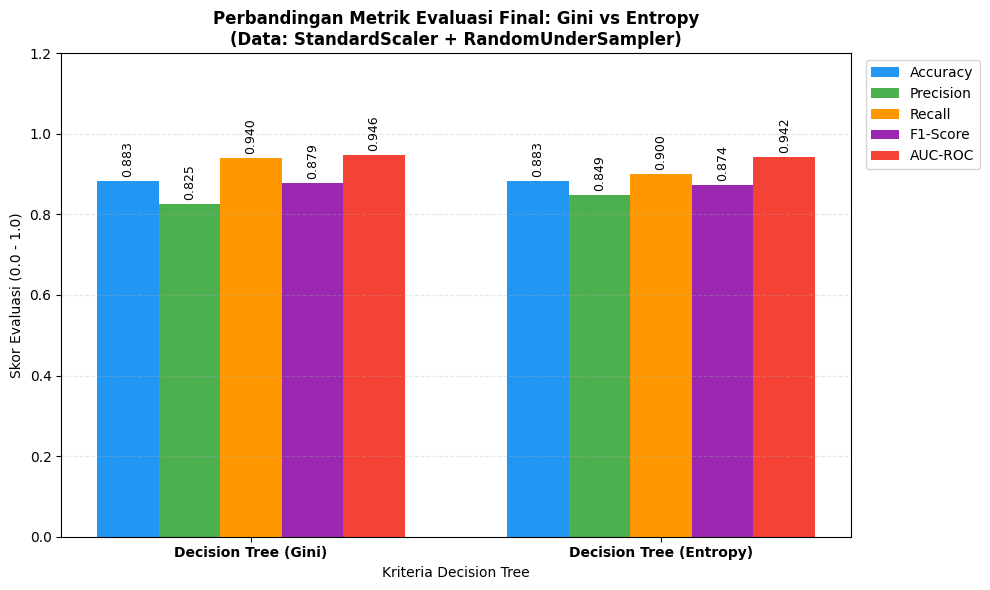


🏁 KESIMPULAN AKHIR PEMBANGUNAN MODEL
1. Anda dapat melihat secara langsung dari grafik di atas, kriteria mana
   (Gini atau Entropy) yang menghasilkan nilai metrik terbaik, terutama pada nilai Recall.
2. Kombinasi preprocessing dan kriteria model pemenang inilah yang dapat
   Anda implementasikan ke dalam file 'app.py' (Aplikasi Streamlit).
3. Seluruh alur (Pipeline) eksperimen Decision Tree untuk deteksi Scabies Sapi SELESAI.


In [ ]:
# ============================================================
# STEP 20: VISUALISASI BAR CHART PERBANDINGAN METRIK FINAL
# ============================================================

# Mempersempit ukuran lebar (figsize) karena kita hanya membandingkan 2 model
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(final_df))
width = 0.15
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

for i, metric in enumerate(metrics_to_plot):
    # Menggambar batang grafik
    bars = ax.bar(x + i * width, final_df[metric], width, label=metric, color=colors[i])
    
    # Menambahkan anotasi angka pasti di atas masing-masing batang
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.3f}', 
                ha='center', va='bottom', fontsize=9, rotation=90)

ax.set_xlabel('Kriteria Decision Tree')
ax.set_ylabel('Skor Evaluasi (0.0 - 1.0)')
ax.set_title(f'Perbandingan Metrik Evaluasi Final: Gini vs Entropy\n(Data: {best_scaler_name} + {best_resampler_name})', fontweight='bold')

# Menyesuaikan posisi label sumbu X agar berada tepat di tengah kelompok batang
ax.set_xticks(x + width * 2)
# Rotasi diubah menjadi 0 (horizontal) karena teks model sekarang cukup pendek
ax.set_xticklabels(final_df['Model'], rotation=0, ha='center', fontweight='bold') 

# Memindahkan posisi legenda (legend) ke luar area grafik agar tidak menutupi batang
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')

# Memberikan ruang ekstra di sumbu Y (sampai 1.2) agar tulisan angka tidak terpotong
ax.set_ylim(0, 1.2)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("🏁 KESIMPULAN AKHIR PEMBANGUNAN MODEL")
print("=" * 70)
print("1. Anda dapat melihat secara langsung dari grafik di atas, kriteria mana")
print("   (Gini atau Entropy) yang menghasilkan nilai metrik terbaik, terutama pada nilai Recall.")
print("2. Kombinasi preprocessing dan kriteria model pemenang inilah yang dapat")
print("   Anda implementasikan ke dalam file 'app.py' (Aplikasi Streamlit).")
print("3. Seluruh alur (Pipeline) eksperimen Decision Tree untuk deteksi Scabies Sapi SELESAI.")

In [ ]:
# ============================================================
# STEP 21: RINGKASAN PENGARUH KOMPONEN PREPROCESSING
# ============================================================
print("RINGKASAN PENGARUH PREPROCESSING PADA DECISION TREE (SCABIES SAPI)")
print("=" * 80)

print("\n1. PENGARUH SCALER (Rata-rata Gini & Entropy dari semua teknik resampling)")
print("-" * 70)
# Catatan Analisis: Pada Decision Tree, Anda kemungkinan besar akan melihat nilai yang identik 
# antar scaler. Ini membuktikan bahwa Decision Tree kebal terhadap perbedaan rentang nilai (skala).
scaler_summary = results_df.groupby('Scaler')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']].mean()
display(scaler_summary.round(4))

print("\n2. PENGARUH TEKNIK RESAMPLER (Rata-rata Gini & Entropy dari semua scaler)")
print("-" * 70)
# Menunjukkan teknik mana (SMOTE, ADASYN, dll) yang paling pintar menyeimbangkan data gejala Scabies
resampler_summary = results_df.groupby('Resampler')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']].mean()
display(resampler_summary.round(4))

print("\n3. PENGARUH KRITERIA DECISION TREE (Gini vs Entropy)")
print("-" * 70)
# Menunjukkan metode pemotongan cabang mana yang paling optimal
model_summary = results_df.groupby('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']].mean()
display(model_summary.sort_values('F1-Score', ascending=False).round(4))

# Rekomendasi Kesimpulan
print("\n" + "=" * 80)
print("🏆 REKOMENDASI UMUM (Fokus: Keseimbangan Metrik / F1-Score):")
print(f"  Scaler Terbaik    : {scaler_summary['F1-Score'].idxmax()} (F1 = {scaler_summary['F1-Score'].max():.4f})")
print(f"  Resampler Terbaik : {resampler_summary['F1-Score'].idxmax()} (F1 = {resampler_summary['F1-Score'].max():.4f})")
print(f"  Kriteria Terbaik  : {model_summary['F1-Score'].idxmax()} (F1 = {model_summary['F1-Score'].max():.4f})")

print("\n🏥 REKOMENDASI KHUSUS MEDIS VETERINER (Fokus: Deteksi Penyakit Menular / Recall Tinggi):")
print(f"  Scaler Terbaik    : {scaler_summary['Recall'].idxmax()} (Recall = {scaler_summary['Recall'].max():.4f})")
print(f"  Resampler Terbaik : {resampler_summary['Recall'].idxmax()} (Recall = {resampler_summary['Recall'].max():.4f})")
print(f"  Kriteria Terbaik  : {model_summary['Recall'].idxmax()} (Recall = {model_summary['Recall'].max():.4f})")

print("\n" + "=" * 80)
print("CATATAN UNTUK LAPORAN:")
print("Silakan gunakan kombinasi dari 'Rekomendasi Khusus Medis' di atas apabila prioritas")
print("utama aplikasi Anda adalah meminimalisir penularan Scabies di kandang (mencegah False Negative).")

RINGKASAN PENGARUH PREPROCESSING PADA DECISION TREE (SCABIES SAPI)

1. PENGARUH SCALER (Rata-rata Gini & Entropy dari semua teknik resampling)
----------------------------------------------------------------------


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Scaler,,,,,
MinMaxScaler,0.9108,0.8574,0.962,0.9066,0.946
RobustScaler,0.9108,0.8574,0.962,0.9066,0.946
StandardScaler,0.9153,0.8780,0.944,0.9094,0.946
Tanpa Scaling,0.9162,0.8671,0.962,0.9118,0.947



2. PENGARUH TEKNIK RESAMPLER (Rata-rata Gini & Entropy dari semua scaler)
----------------------------------------------------------------------


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Resampler,,,,,
ADASYN,0.8998,0.8563,0.9350,0.8937,0.9443
RandomUnderSampler,0.9189,0.8596,0.9800,0.9159,0.9407
SMOTE,0.9189,0.8769,0.9550,0.9138,0.9554
SMOTETomek,0.9189,0.8749,0.9575,0.9141,0.9538
Tanpa Resampling,0.9099,0.8571,0.9600,0.9057,0.9370



3. PENGARUH KRITERIA DECISION TREE (Gini vs Entropy)
----------------------------------------------------------------------


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
Decision Tree (Gini),0.9140,0.8686,0.954,0.9090,0.9483
Decision Tree (Entropy),0.9126,0.8613,0.961,0.9083,0.9442



🏆 REKOMENDASI UMUM (Fokus: Keseimbangan Metrik / F1-Score):
  Scaler Terbaik    : Tanpa Scaling (F1 = 0.9118)
  Resampler Terbaik : RandomUnderSampler (F1 = 0.9159)
  Kriteria Terbaik  : Decision Tree (Gini) (F1 = 0.9090)

🏥 REKOMENDASI KHUSUS MEDIS VETERINER (Fokus: Deteksi Penyakit Menular / Recall Tinggi):
  Scaler Terbaik    : MinMaxScaler (Recall = 0.9620)
  Resampler Terbaik : RandomUnderSampler (Recall = 0.9800)
  Kriteria Terbaik  : Decision Tree (Entropy) (Recall = 0.9610)

CATATAN UNTUK LAPORAN:
Silakan gunakan kombinasi dari 'Rekomendasi Khusus Medis' di atas apabila prioritas
utama aplikasi Anda adalah meminimalisir penularan Scabies di kandang (mencegah False Negative).


In [ ]:
# ============================================================
# STEP 22: KESIMPULAN AKHIR & REKOMENDASI MODEL TERBAIK
# ============================================================
print("=" * 80)
print("KESIMPULAN AKHIR - REKOMENDASI MODEL TERBAIK UNTUK SCABIES SAPI")
print("=" * 80)

# 1. Overall best (Keseimbangan terbaik antara Precision dan Recall)
best = results_df.sort_values('F1-Score', ascending=False).iloc[0]
print(f"\n🏆 KOMBINASI TERBAIK SECARA KESELURUHAN (Berdasarkan F1-Score):")
print(f"   Kriteria Model : {best['Model']}")
print(f"   Scaler         : {best['Scaler']}")
print(f"   Resampler      : {best['Resampler']}")
print(f"   Accuracy       : {best['Accuracy']:.4f}")
print(f"   Precision      : {best['Precision']:.4f}")
print(f"   Recall         : {best['Recall']:.4f}")
print(f"   F1-Score       : {best['F1-Score']:.4f}")
print(f"   AUC-ROC        : {best['AUC-ROC']:.4f}")

# 2. Best for Veterinary Screening 
# (Fokus pada Recall tertinggi. Menggunakan sorting ganda agar jika ada Recall yang sama, dipilih Precision yang lebih baik)
best_recall = results_df.sort_values(by=['Recall', 'Precision'], ascending=[False, False]).iloc[0]
print(f"\n🏥 TERBAIK UNTUK SCREENING VETERINER (Prioritas Recall Tertinggi):")
print(f"   (Sangat direkomendasikan untuk mencegah sapi sakit lolos dari deteksi / menekan False Negative)")
print(f"   Kriteria Model : {best_recall['Model']}")
print(f"   Scaler         : {best_recall['Scaler']}")
print(f"   Resampler      : {best_recall['Resampler']}")
print(f"   Recall         : {best_recall['Recall']:.4f}")
print(f"   Precision      : {best_recall['Precision']:.4f}")
print(f"   F1-Score       : {best_recall['F1-Score']:.4f}")

# 3. Best AUC
best_auc = results_df.sort_values('AUC-ROC', ascending=False).iloc[0]
print(f"\n📊 TERBAIK DALAM MEMBEDAKAN KELAS (Berdasarkan AUC-ROC):")
print(f"   Kriteria Model : {best_auc['Model']}")
print(f"   Scaler         : {best_auc['Scaler']}")
print(f"   Resampler      : {best_auc['Resampler']}")
print(f"   AUC-ROC        : {best_auc['AUC-ROC']:.4f}")
print(f"   F1-Score       : {best_auc['F1-Score']:.4f}")

print("\n" + "=" * 80)
# Menghitung otomatis jumlah eksperimen yang ada di DataFrame
total_eksperimen = len(results_df)
print(f"✅ Eksperimen Selesai! Total {total_eksperimen} kombinasi pra-pemrosesan dan kriteria Decision Tree")
print("telah berhasil dijalankan, dievaluasi, dan dianalisis untuk dataset Scabies Sapi.")
print("=" * 80)

KESIMPULAN AKHIR - REKOMENDASI MODEL TERBAIK UNTUK SCABIES SAPI

🏆 KOMBINASI TERBAIK SECARA KESELURUHAN (Berdasarkan F1-Score):
   Kriteria Model : Decision Tree (Gini)
   Scaler         : StandardScaler
   Resampler      : RandomUnderSampler
   Accuracy       : 0.9189
   Precision      : 0.8596
   Recall         : 0.9800
   F1-Score       : 0.9159
   AUC-ROC        : 0.9408

🏥 TERBAIK UNTUK SCREENING VETERINER (Prioritas Recall Tertinggi):
   (Sangat direkomendasikan untuk mencegah sapi sakit lolos dari deteksi / menekan False Negative)
   Kriteria Model : Decision Tree (Gini)
   Scaler         : StandardScaler
   Resampler      : RandomUnderSampler
   Recall         : 0.9800
   Precision      : 0.8596
   F1-Score       : 0.9159

📊 TERBAIK DALAM MEMBEDAKAN KELAS (Berdasarkan AUC-ROC):
   Kriteria Model : Decision Tree (Gini)
   Scaler         : Tanpa Scaling
   Resampler      : ADASYN
   AUC-ROC        : 0.9595
   F1-Score       : 0.9143

✅ Eksperimen Selesai! Total 40 kombinasi pra-p